In [1]:
# Cell 1: Master Dependencies and Library Imports

import os          
import glob        
import gc       

import numpy as np
import pandas as pd

import MDAnalysis as mda
from MDAnalysis import transformations      
from MDAnalysis.analysis import align      
from MDAnalysis.analysis import rms         
from MDAnalysis.analysis import dssp      
import pyKVFinder                        
import prolif as plf                     
import freesasa                             
from mdakit_sasa.analysis.sasaanalysis import SASAAnalysis
import networkx as nx

import matplotlib.pyplot as plt              
import matplotlib.ticker as ticker   
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns                        

from tqdm.auto import tqdm   
freesasa.setVerbosity(freesasa.nowarnings)

sns.set_context("notebook", font_scale=1.2)
sns.set_style("whitegrid")

/home/sfuentes/miniconda3/envs/MDAnalysis/lib/python3.10/site-packages/MDAnalysis/topology/tables.py:52: DeprecationWarning: Deprecated in version 2.8.0
MDAnalysis.topology.tables has been moved to MDAnalysis.guesser.tables. This import point will be removed in MDAnalysis version 3.0.0
  warnings.warn(wmsg, category=DeprecationWarning)


# TRAJECTORY LOADING
__Important__ 
Need to set Topology path and trajectories.

Remember to __set protein_length__ 

AT1R : 310

AT2R : 306

MAS2 : 253

In [2]:
# Cell 2.6: Global Filename & Plot Configuration

# --- 1. System  ---
system = "MAS2"
system_prefix = "A18"
length = {
    "AT1R": 310, # Replace with your actual length values
    "AT2R": 306,
    "MAS2": 253
}

# --- 2. Structural Metrics Filenames ---
fn_rmsd_csv = f"{system_prefix}_RMSD_Data.csv"
fn_rmsd_png = f"{system_prefix}_RMSD_Plot.png"
fn_rmsd_pdf = f"{system_prefix}_RMSD_Plot.pdf"

fn_rmsf_prot_csv = f"{system_prefix}_Receptor_RMSF_Data.csv"
fn_rmsf_prot_png = f"{system_prefix}_Receptor_RMSF_Plot.png"
fn_rmsf_prot_pdf = f"{system_prefix}_Receptor_RMSF_Plot.pdf"

fn_rmsf_lig_csv  = f"{system_prefix}_Ligand_RMSF_Data.csv"
fn_rmsf_lig_png  = f"{system_prefix}_Ligand_RMSF_Plot.png"
fn_rmsf_lig_pdf  = f"{system_prefix}_Ligand_RMSF_Plot.pdf"

fn_high_mob_prot = f"{system_prefix}_High_Mobility_Receptor.csv"
fn_high_mob_lig  = f"{system_prefix}_High_Mobility_Ligand.csv"

# --- 3. Secondary Structure Filenames ---
fn_ss_prot_csv         = f"{system_prefix}_Receptor_SS_Distribution.csv"
fn_ss_prot_png         = f"{system_prefix}_Receptor_SS_StackedBar.png"
fn_ss_prot_pdf         = f"{system_prefix}_Receptor_SS_StackedBar.pdf"
fn_ss_prot_heat_png    = f"{system_prefix}_Receptor_SS_Heatmap.png"
fn_ss_prot_heat_pdf    = f"{system_prefix}_Receptor_SS_Heatmap.pdf"
fn_ss_prot_comp_png    = f"{system_prefix}_Receptor_SS_Composite.png"
fn_ss_prot_comp_pdf    = f"{system_prefix}_Receptor_SS_Composite.pdf"
fn_ss_prot_per_res_csv = f"{system_prefix}_Receptor_SS_Per_Res.csv"

fn_ss_lig_csv          = f"{system_prefix}_Ligand_SS_Distribution.csv"
fn_ss_lig_png          = f"{system_prefix}_Ligand_SS_StackedBar.png"
fn_ss_lig_pdf          = f"{system_prefix}_Ligand_SS_StackedBar.pdf"
fn_ss_lig_heat_png     = f"{system_prefix}_Ligand_SS_Heatmap.png"
fn_ss_lig_heat_pdf     = f"{system_prefix}_Ligand_SS_Heatmap.pdf"
fn_ss_lig_comp_png     = f"{system_prefix}_Ligand_SS_Composite.png"
fn_ss_lig_comp_pdf     = f"{system_prefix}_Ligand_SS_Composite.pdf"
fn_ss_lig_per_res_csv  = f"{system_prefix}_Ligand_SS_Per_Res.csv"

# --- 4. Intramolecular (ProLIF Protein-Protein) Filenames ---
fn_intra_csv           = f"{system_prefix}_Intramolecular_Interactions.csv"
fn_intra_detailed_csv  = f"{system_prefix}_Detailed_Intra_Edges.csv" 
fn_intra_helix_net_csv = f"{system_prefix}_Helix_to_Helix_Network.csv"
fn_intra_helix_top_png = f"{system_prefix}_Helical_Topology.png"
fn_intra_helix_top_pdf = f"{system_prefix}_Helical_Topology.pdf"
fn_intra_loop_net_png  = f"{system_prefix}_Loop_Network_Preview.png"
fn_intra_loop_net_pdf  = f"{system_prefix}_Loop_Network_Preview.pdf"
fn_intra_tm_graphml    = f"{system_prefix}_Cytoscape_TM_Wheels.graphml"
fn_intra_loop_graphml  = f"{system_prefix}_Cytoscape_Loops.graphml"

# --- 5. Intermolecular (ProLIF Ligand-Protein) Filenames ---
fn_inter_csv          = f"{system_prefix}_Intermolecular_Interactions.csv"
fn_inter_detailed_csv = f"{system_prefix}_Detailed_Inter_Edges.csv" # <--- NEW INTER CYTOSCAPE FILE ADDED HERE
fn_inter_net_png      = f"{system_prefix}_Binding_Network.png"
fn_inter_net_pdf      = f"{system_prefix}_Binding_Network.pdf"
fn_inter_graphml      = f"{system_prefix}_Cytoscape_Binding.graphml"

# --- 6. SASA and Cavity Volume Filenames ---
fn_sasa_csv = f"{system_prefix}_Intracellular_Pocket_SASA.csv"
fn_sasa_png = f"{system_prefix}_Intracellular_SASA_Plot.png"
fn_sasa_pdf = f"{system_prefix}_Intracellular_SASA_Plot.pdf"

fn_vol_csv  = f"{system_prefix}_Intracellular_Pocket_Volume.csv"
fn_vol_png  = f"{system_prefix}_Intracellular_Volume_Plot.png"
fn_vol_pdf  = f"{system_prefix}_Intracellular_Volume_Plot.pdf"

print(f"Global filenames initialized with prefix: '{system_prefix}'")

Global filenames initialized with prefix: 'A18'


# Structure loading

In [3]:
# Cell 2

topology_search = glob.glob(f'{system}/{system_prefix}/*.prmtop')

if topology_search:
    topology_path = topology_search[0]  # Grab the first (and only) file found
else:
    topology_path = None
    print(f"ERROR: No .prmtop file found in {system}/{system_prefix}/")

# Trajectories
trajectory_files = sorted(glob.glob(f'{system}/{system_prefix}/*.nc'))

# PATH
print(f"Topology defined as: {topology_path}")
print(f"Found {len(trajectory_files)} trajectory files:")
for traj in trajectory_files:
    print(f" - {traj}")

Topology defined as: MAS2/A18/MAS2_A18_model_1.prmtop
Found 3 trajectory files:
 - MAS2/A18/MAS2_A18_model_1_prod_r1.nc
 - MAS2/A18/MAS2_A18_model_1_prod_r2.nc
 - MAS2/A18/MAS2_A18_model_1_prod_r3.nc


In [4]:
# Cell 2.5: Load Virtual Concatenated Trajectory and Extract Time

print("Initializing Virtual Concatenation...")

# The * operator unpacks the Python list
u_concat = mda.Universe(topology_path, *trajectory_files)
total_frames = len(u_concat.trajectory)

replicate_boundaries_frames = []
replicate_boundaries_time_ns = []
current_frame_count = 0
current_time_ps = 0.0

# Extract and print the time step from the first file's metadata
temp_u_first = mda.Universe(topology_path, trajectory_files[0])
detected_dt_ps = temp_u_first.trajectory.dt
print(f"Detected Time Step (dt) from metadata: {detected_dt_ps} ps\n")
del temp_u_first

for traj in trajectory_files:
    # Temporarily load just the single trajectory
    temp_u = mda.Universe(topology_path, traj)
    
    frames = len(temp_u.trajectory)
    dt_ps = temp_u.trajectory.dt 
    
    current_frame_count += frames
    current_time_ps += (frames * dt_ps)
    
    replicate_boundaries_frames.append(current_frame_count)
    replicate_boundaries_time_ns.append(current_time_ps / 1000.0)  # Convert to ns
    
    del temp_u

total_time_ns = current_time_ps / 1000.0

print(f"Successfully linked {len(trajectory_files)} replicates into memory.")
print(f"Total Concatenated Frames: {total_frames}")
print(f"Total Simulated Time: {total_time_ns:.2f} ns")
print(f"Replicate Boundaries (Frames): {replicate_boundaries_frames[:-1]}")
print(f"Replicate Boundaries (Time in ns): {replicate_boundaries_time_ns[:-1]}")

Initializing Virtual Concatenation...
Detected Time Step (dt) from metadata: 500.0 ps

Successfully linked 3 replicates into memory.
Total Concatenated Frames: 3000
Total Simulated Time: 1500.00 ns
Replicate Boundaries (Frames): [1000, 2000]
Replicate Boundaries (Time in ns): [np.float32(500.0), np.float32(1000.0)]


# Protein Index ID

In [5]:
# Cell 2.9: Identification of protein and ligand sequences.

# Safely resolve the topology wildcard to an exact file path
u = mda.Universe(topology_path)

all_protein_like = u.select_atoms("protein")
all_residues = all_protein_like.residues

if system in length:
    protein_length = length[system]
    print(f"System recognized. Length set to: {protein_length}")
else:
    print(f"System '{system}' not recognized. Please set protein_length manually.")
 # <------------------------------------------------------- PROTEIN LENGTH ------------------------------------------------------

print("=== ENTIRE AMBER CHAIN ===")
print(f"Total Amino Acid Residues Found: {len(all_residues)}")

# --- THE FIX: Initialize Global Variables ---
protein_sel_str = ""
ligand_sel_str = None
has_ligand = False
# --------------------------------------------

# 3. Mathematically split the chain based on the known GPCR length (310)
if len(all_residues) > protein_length:
    has_ligand = True
    receptor_residues = all_residues[:protein_length]
    ligand_residues = all_residues[protein_length:]
    
    # Generate the dynamic strings
    protein_sel_str = f"resid {receptor_residues.resids[0]}-{receptor_residues.resids[-1]}"
    ligand_sel_str = f"resid {ligand_residues.resids[0]}-{ligand_residues.resids[-1]}"

    print("\n=== RECEPTOR ===")
    print(f"Residue Count: {len(receptor_residues)}")
    print(f"Selection String: '{protein_sel_str}'")

    print("\n=== LIGAND ===")
    print(f"Residue Count: {len(ligand_residues)}")
    print(f"Selection String: '{ligand_sel_str}'")
    
    ligand_seq = "-".join([res.resname for res in ligand_residues])
    print(f"Ligand Sequence:\n{ligand_seq}\n")
    
else:
    has_ligand = False
    protein_sel_str = f"resid {all_residues.resids[0]}-{all_residues.resids[-1]}"
    
    print("The ligand is missing from this topology (APO system).")
    print(f"Receptor Selection String: '{protein_sel_str}'")

System recognized. Length set to: 253
=== ENTIRE AMBER CHAIN ===
Total Amino Acid Residues Found: 261

=== RECEPTOR ===
Residue Count: 253
Selection String: 'resid 1-253'

=== LIGAND ===
Residue Count: 8
Selection String: 'resid 254-261'
Ligand Sequence:
ASP-ARG-VAL-TYR-ILE-HIE-PRO-PHE



/home/sfuentes/miniconda3/envs/MDAnalysis/lib/python3.10/site-packages/MDAnalysis/core/universe.py:150: UserWarning: No coordinate reader found for MAS2/A18/MAS2_A18_model_1.prmtop. Skipping this file.
  warnings.warn('No coordinate reader found for {}. Skipping '


# RMSD Calculations

#### __Remember__ to set the __LIGAND SELECTION__

In [49]:
# Cell 3: Concatenated RMSD Calculation (Protein & Ligand)

print("Calculating concatenated RMSD for Protein and Ligand...")

# 1. Create a static reference to the absolute starting point of the simulation
ref = mda.Universe(topology_path, trajectory_files[0])
ref.trajectory[0]

# 2. Define the structural masks dynamically based on Cell 2.9
protein_sel = f"{protein_sel_str} and name CA"
group_sels = []

if has_ligand:
    ligand_sel = f"{ligand_sel_str} and not name H*"
    group_sels.append(ligand_sel)

# 3. Pass the concatenated universe into the active calculation
R = rms.RMSD(u_concat, 
             ref, 
             select=protein_sel,             
             groupselections=group_sels  
            )

R.run()

# 4. Extract the data matrix dynamically into a clean DataFrame
data_dict = {
    'Frame': R.results.rmsd[:, 0],
    'Time_ps': R.results.rmsd[:, 1], 
    'Time_ns': R.results.rmsd[:, 1] / 1000,
    'Protein_RMSD': R.results.rmsd[:, 2]
}

# Only add the ligand column if a ligand actually exists
if has_ligand:
    data_dict['Ligand_RMSD'] = R.results.rmsd[:, 3] 

df_rmsd_all = pd.DataFrame(data_dict)

df_rmsd_all.to_csv(fn_rmsd_csv, index=False)

print(f"RMSD Calculation complete. Data saved to: {fn_rmsd_csv}")
display(df_rmsd_all.head())

Calculating concatenated RMSD for Protein and Ligand...
RMSD Calculation complete. Data saved to: CONTROL_RMSD_Data.csv


,Frame,Time_ps,Time_ns,Protein_RMSD
0,0.0,1505.0,1.505,5.874561e-07
1,1.0,2005.0,2.005,9.597802e-01
2,2.0,2505.0,2.505,9.370701e-01
3,3.0,3005.0,3.005,1.070902e+00
4,4.0,3505.0,3.505,9.636986e-01


Generating RMSD visualization...


KeyError: 'Ligand_RMSD'

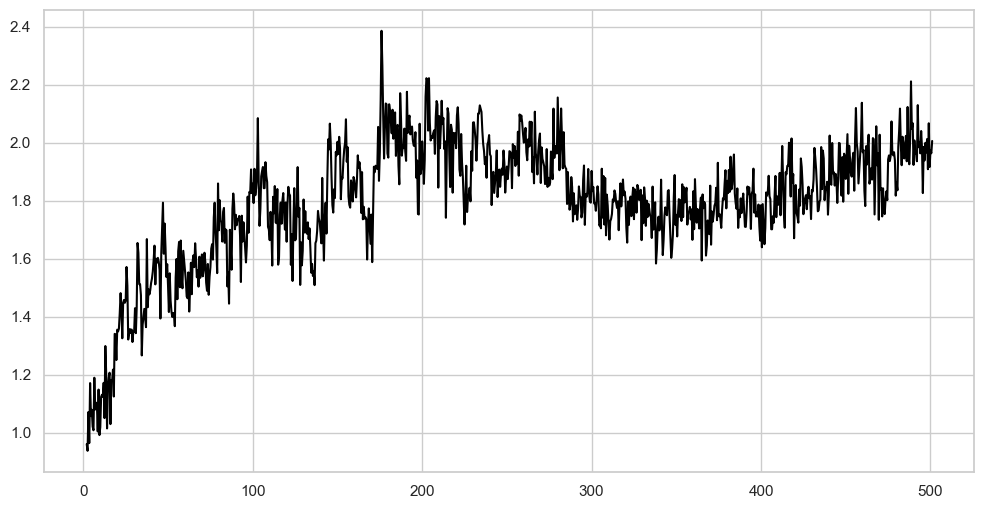

In [50]:
# Cell 4: Plotting the RMSD

import matplotlib.ticker as ticker

x_tick_interval = 250 # <------------------------------------- TICKS ------------------------------------------------------------->

sns.set_context("notebook")
sns.set_style("whitegrid")

print("Generating RMSD visualization...")

# 1. Create a visualization-only slice that drops Frame 0 
plot_df = df_rmsd_all.iloc[1:].copy()
max_time = plot_df['Time_ns'].max()

# 2. Initialize the unified plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(plot_df['Time_ns'], plot_df['Protein_RMSD'], color='black', linewidth=1.5, label='AT1R Backbone')

########## Ligand ##########
ax.plot(plot_df['Time_ns'], plot_df['Ligand_RMSD'], color='crimson', linewidth=1.5, label='Ligand') # ------------------------------------------------------
########## /Ligand ##########


# --- THE FIX: Pure Custom Spacing ---
# 1. Set the spacing between major ticks manually using your variable
ax.xaxis.set_major_locator(ticker.MultipleLocator(x_tick_interval))
fig.canvas.draw() # Force a draw to populate the ticks
current_ticks = list(ax.get_xticks())

# 2. Keep the generated ticks strictly within the valid time range (but less than max_time)
valid_ticks = [t for t in current_ticks if 0 <= t < max_time]

# 3. Append your exact final frame safely
valid_ticks.append(int(max_time))

ax.set_xticks(valid_ticks)
ax.set_xticklabels([f"{t:g}" for t in valid_ticks])
# ------------------------------------


# --- TITLES AND LABELS ---
ax.set_title(f"RMSD: {system_prefix}", fontsize=16, fontweight='bold')
ax.set_xlabel("Time (ns)", fontsize=14)
ax.set_ylabel("RMSD (Å)", fontsize=14)

# Force the X-axis to start at zero and end exactly at max_time
ax.set_xlim(0, max_time)
ax.set_ylim(0, 17.0) # <---------------------------------------------------------------- Y Axys Limit ------------------------------------>

ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=True)
plt.tight_layout()

# 3. Save Plot to the root directory
plt.savefig(fn_rmsd_png, dpi=1200, format='png', bbox_inches='tight')
plt.savefig(fn_rmsd_pdf, format='pdf', bbox_inches='tight')
print(f"Plot safely saved as {fn_rmsd_png} and {fn_rmsd_pdf}")

plt.show()

# RMSF Calculations

If running systems of receptor-ligand complexes, Be careful with defining the __ligand residue index__, as well as the __protein index__

In [17]:
# Cell 5: Concatenated Trajectory Analysis (RMSF)

print("Aligning concatenated trajectory and calculating RMSF...")

# --- THE FIX: Make the cell self-sufficient ---
# Re-establish the reference universe locally so it never relies on Cell 3
ref = mda.Universe(topology_path, trajectory_files[0])
ref.trajectory[0]
# ----------------------------------------------

# STRICT ALIGNMENT: We strictly align ONLY on the receptor backbone using dynamic boundaries. 
align_mask = f'{protein_sel_str} and name CA'

# Define the separate targets using the dynamic strings
calc_masks = {
    'Protein': f'{protein_sel_str} and name CA'
}

if has_ligand:
    calc_masks['Ligand'] = f'{ligand_sel_str} and name CA'

# 1. Align the entire concatenated universe in memory
print(f"Executing in-memory alignment on: '{align_mask}'...")
align.AlignTraj(u_concat, ref, select=align_mask, in_memory=True).run()

# Create a flat dictionary to temporarily store the final DataFrames
rmsf_results = {}

# 2. Calculate RMSF for all dynamic targets
for target_name, mask_string in calc_masks.items():
    print(f"Calculating RMSF for {target_name}...")
    target_atoms = u_concat.select_atoms(mask_string)
    
    # Execute the RMSF calculation across the unified trajectory
    rmsf_calc = rms.RMSF(target_atoms).run()
    
    # Structure directly into a Pandas DataFrame
    df_target = pd.DataFrame({
        'Residue': target_atoms.resids,
        'RMSF_Å': rmsf_calc.rmsf
    })
    
    df_target.set_index('Residue', inplace=True)
    rmsf_results[target_name] = df_target

# 3. Extract into explicit variables for downstream plotting
df_rmsf_protein = rmsf_results['Protein']
df_rmsf_ligand = rmsf_results.get('Ligand', None) 

print("RMSF calculation complete. Data structured.")
display(df_rmsf_protein.head())

Aligning concatenated trajectory and calculating RMSF...
Executing in-memory alignment on: 'resid 1-253 and name CA'...
Calculating RMSF for Protein...
RMSF calculation complete. Data structured.


/home/sfuentes/miniconda3/envs/MDAnalysis/lib/python3.10/site-packages/MDAnalysis/analysis/rms.py:1000: DeprecationWarning: The `rmsf` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


,RMSF_Å
Residue,
1,1.376462
2,1.054932
3,1.015771
4,0.977371
5,0.814627


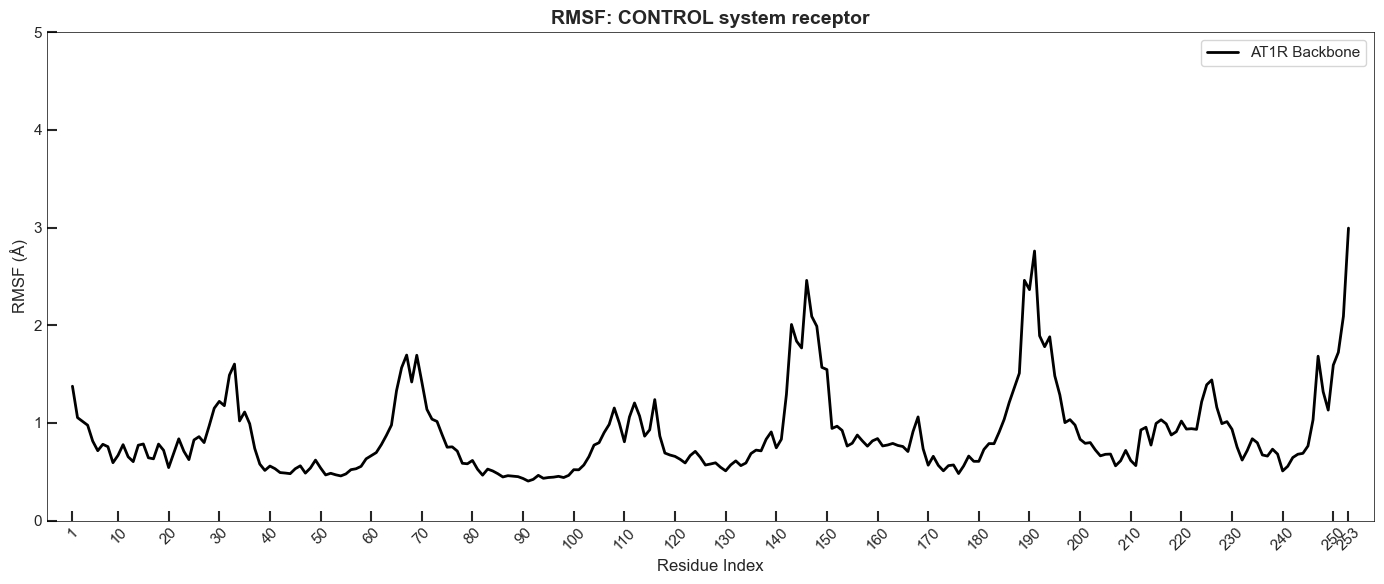

In [18]:
# Cell 6: Plotting Concatenated Protein and Ligand RMSF

sns.set_theme(style="ticks")

# ==============================================================================
# 1. PROTEIN RMSF PLOT
# ==============================================================================
fig1, ax1 = plt.subplots(figsize=(14, 6))

# Plot the single concatenated RMSF array directly
ax1.plot(df_rmsf_protein.index, df_rmsf_protein['RMSF_Å'], color='black', linewidth=2.0, label='AT1R Backbone')

ax1.set_xlabel('Residue Index', fontsize=12)
ax1.set_ylabel('RMSF (Å)', fontsize=12)
ax1.set_title(f'RMSF: {system_prefix} system receptor', fontsize=14, fontweight='bold')

# <-------------------------------------------------------------------- Y Axys ------------------------------------------------------------------------->
ax1.set_ylim(0, 5)

# Custom X-Axis Ticks
prot_len = len(df_rmsf_protein)
custom_ticks = [1] + list(np.arange(10, prot_len + 1, 10))
if prot_len not in custom_ticks:
    custom_ticks.append(prot_len) 
    
ax1.set_xticks(custom_ticks)

# Apply your custom spine and tick styling
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

ax1.tick_params(which='major', length=7, width=1.5, direction='in')
ax1.tick_params(which='minor', length=4, width=1, direction='in')
ax1.margins(x=0.02)
plt.xticks(rotation=45)

ax1.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Save directly to the root directory
plt.savefig(f"{system_prefix}_Receptor_RMSF_Plot.png", dpi=1200, format='png', bbox_inches='tight')
plt.savefig(f"{system_prefix}_Receptor_RMSF_Plot.pdf", format='pdf', bbox_inches='tight')
plt.show()

# ==============================================================================
# 2. LIGAND RMSF PLOT 
# ==============================================================================
# The .get() method in Cell 5 set df_rmsf_ligand to None if not analyzing A18
if df_rmsf_ligand is not None:
    fig2, ax2 = plt.subplots(figsize=(8, 5))

    # Added markers to the ligand plot since it only has 8 residues
    ax2.plot(df_rmsf_ligand.index, df_rmsf_ligand['RMSF_Å'], color='crimson', 
             linewidth=2.0, marker='o', markersize=6, label='Ligand')

    ax2.set_xlabel('Peptide Residue Index', fontsize=12)
    ax2.set_ylabel('RMSF (Å)', fontsize=12)
    ax2.set_title(f"RMSF: {system_prefix} ligand", fontsize=14, fontweight='bold')
    
    # <----------------------------------------------------------------------------- Y Axys -----------------------------------------------------------------------
    ax2.set_ylim(0, 10)

    ax2.set_xticks(df_rmsf_ligand.index)

    for spine in ax2.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)

    ax2.tick_params(which='major', length=7, width=1.5, direction='in')
    ax2.margins(x=0.05)
    
    ax2.legend(loc='upper right', frameon=True)
    plt.tight_layout()
    
    plt.savefig(f"{system_prefix}_Ligand_RMSF_Plot.png", dpi=1200, format='png', bbox_inches='tight')
    plt.savefig(f"{system_prefix}_Ligand_RMSF_Plot.pdf", format='pdf', bbox_inches='tight')
    plt.show()

In [19]:
# Cell 7: Export RMSF Data & Identify High-Mobility Residues
print("Saving raw concatenated RMSF data to root directory...")

# Save the raw data
df_rmsf_protein.to_csv(f"{system_prefix}_Receptor_RMSF_Data.csv")
if df_rmsf_ligand is not None:
    df_rmsf_ligand.to_csv(f"{system_prefix}_Ligand_RMSF_Data.csv")

def analyze_high_mobility(df, molecule_name, threshold=1.5):
    """Filters for RMSF values above a threshold, prints a summary, and returns the filtered DataFrame."""
    
    # Isolate all rows that cross the threshold using the exact column name from Cell 5
    high_rmsf_df = df[df['RMSF_Å'] >= threshold].copy()
    flexible_residues = high_rmsf_df.index.tolist()

    # Algorithmic grouping for the notebook printout
    def group_consecutive_residues(residue_list):
        ranges = []
        if not residue_list: return ranges
        start = end = residue_list[0]
        for res in residue_list[1:]:
            if res == end + 1:
                end = res
            else:
                ranges.append((start, end))
                start = end = res
        ranges.append((start, end))
        return ranges

    loop_regions = group_consecutive_residues(flexible_residues)
    
    # Print the visual summary to the notebook output
    print(f"\nHighly Flexible Regions: {molecule_name} (Concatenated RMSF >= {threshold} Å)")
    print("-" * 55)

    if not loop_regions:
        print("No residues crossed the threshold.")
    else:
        for start, end in loop_regions:
            if start == end:
                rmsf_val = df.loc[start, 'RMSF_Å']
                print(f"Isolated Residue: {start} \t\t(RMSF: {rmsf_val:.2f} Å)")
            else:
                max_rmsf = df.loc[start:end, 'RMSF_Å'].max()
                print(f"Loop Segment: Residues {start} to {end} \t(Peak RMSF: {max_rmsf:.2f} Å)")

    # Return the full, raw DataFrame containing every single passing residue
    return high_rmsf_df

# 1. Execute and store the Receptor data
df_high_mob_receptor = analyze_high_mobility(df_rmsf_protein, "Receptor")

# 2. Conditionally execute and store the Ligand data
# We use the 'is not None' check because of how we handled the dictionary extraction in Cell 5
if df_rmsf_ligand is not None:
    df_high_mob_ligand = analyze_high_mobility(df_rmsf_ligand, "Ligand")
else:
    print("\nSkipped ligand mobility analysis (CONTROL system run or ligand not found).")

Saving raw concatenated RMSF data to root directory...

Highly Flexible Regions: Receptor (Concatenated RMSF >= 1.5 Å)
-------------------------------------------------------
Isolated Residue: 33 		(RMSF: 1.60 Å)
Loop Segment: Residues 66 to 67 	(Peak RMSF: 1.70 Å)
Isolated Residue: 69 		(RMSF: 1.69 Å)
Loop Segment: Residues 143 to 150 	(Peak RMSF: 2.46 Å)
Loop Segment: Residues 188 to 194 	(Peak RMSF: 2.76 Å)
Isolated Residue: 247 		(RMSF: 1.68 Å)
Loop Segment: Residues 250 to 253 	(Peak RMSF: 3.00 Å)

Skipped ligand mobility analysis (CONTROL system run or ligand not found).


In [20]:
# Cell 8: Export Mobility Data to CSV

# 1. Export Receptor Data
if not df_high_mob_receptor.empty:
    # index=True is mandatory here because the index contains your residue numbers
    df_high_mob_receptor.to_csv(fn_high_mob_prot, index=True)
    print(f"Saved detailed residue data to: {fn_high_mob_prot}")
else:
    print("Receptor: No high mobility data to save.")

# 2. Conditionally Export Ligand Data
if 'df_high_mob_ligand' in globals():
    if not df_high_mob_ligand.empty:
        df_high_mob_ligand.to_csv(fn_high_mob_lig, index=True)
        print(f"Saved detailed residue data to: {fn_high_mob_lig}")
    else:
        print("Ligand: No high mobility data to save.")
else:
    print("Skipped saving ligand data (CONTROL system run or data not found).")

Saved detailed residue data to: CONTROL_High_Mobility_Receptor.csv
Saved detailed residue data to: CONTROL_High_Mobility_Ligand.csv


# Secondary Structure Content Determination

In [53]:
# Cell 8: Calculate Secondary Structure (DSSP)

print("Starting MDAnalysis DSSP calculation...")

# --- Dynamic Selection Configuration ---
dssp_masks = {
    'Protein': f'protein and {protein_sel_str}' 
}

if has_ligand:
    dssp_masks['Ligand'] = ligand_sel_str
# ---------------------------------------

# Dictionary to store the final DataFrames
dssp_results = {}

for target_name, mask_string in dssp_masks.items():
    # Isolate the specific molecule from the unified timeline
    selection = u_concat.select_atoms(mask_string)
    
    # Dynamic Check: Skip if the selection finds 0 atoms
    if len(selection) == 0:
        print(f" -> Skipping {target_name}: No atoms found for mask '{mask_string}'.")
        continue
        
    print(f"Executing DSSP for {target_name}...")
    
    # Execute DSSP specifically on this isolated selection
    dssp_calc = dssp.DSSP(selection).run()
    
    # Extract the full time-series array directly from the results
    combined_ss = dssp_calc.results.dssp
    total_frames = combined_ss.shape[0]
    
    # Vectorized counting
    helix_counts = np.isin(combined_ss, ['H', 'G', 'I']).sum(axis=0)
    sheet_counts = np.isin(combined_ss, ['E', 'B']).sum(axis=0)
    coil_counts = total_frames - (helix_counts + sheet_counts)
    
    # Construct the DataFrame
    df_temp = pd.DataFrame({'Residue': selection.residues.resids})
    df_temp['Helix_%'] = (helix_counts / total_frames) * 100
    df_temp['Sheet_%'] = (sheet_counts / total_frames) * 100
    df_temp['Coil_%'] = (coil_counts / total_frames) * 100
    df_temp.set_index('Residue', inplace=True)
    
    # Determine dominant state
    conditions = [
        (df_temp['Helix_%'] >= 50),
        (df_temp['Sheet_%'] >= 50),
        (df_temp['Coil_%'] >= 50)
    ]
    choices = ['Alpha Helix', 'Beta Sheet', 'Coil']
    df_temp['Dominant_SS'] = np.select(conditions, choices, default='Mixed')
    
    dssp_results[target_name] = df_temp

print("\nAnalysis complete. Exporting data...")

# --- Extract and Export Data ---
df_ss_protein = None
df_ss_ligand = None

# 1. Receptor Output
if 'Protein' in dssp_results:
    df_ss_protein = dssp_results['Protein']
    df_ss_protein.to_csv(fn_ss_prot_csv, index=True)
    print(f"Saved: {fn_ss_prot_csv}")

# 2. Ligand Output (Only executes if ligand exists)
if 'Ligand' in dssp_results:
    df_ss_ligand = dssp_results['Ligand']
    df_ss_ligand.to_csv(fn_ss_lig_csv, index=True)
    print(f"Saved: {fn_ss_lig_csv}")

# Verify Receptor output
if df_ss_protein is not None:
    display(df_ss_protein.head(10))

Starting MDAnalysis DSSP calculation...
Executing DSSP for Protein...

Analysis complete. Exporting data...
Saved: CONTROL_Receptor_SS_Distribution.csv


,Helix_%,Sheet_%,Coil_%,Dominant_SS
Residue,,,,
1,0.0,0.0,100.0,Coil
2,0.0,0.0,100.0,Coil
3,0.0,0.0,100.0,Coil
4,99.1,0.0,0.9,Alpha Helix
5,100.0,0.0,0.0,Alpha Helix
6,100.0,0.0,0.0,Alpha Helix
7,100.0,0.0,0.0,Alpha Helix
8,100.0,0.0,0.0,Alpha Helix
9,100.0,0.0,0.0,Alpha Helix


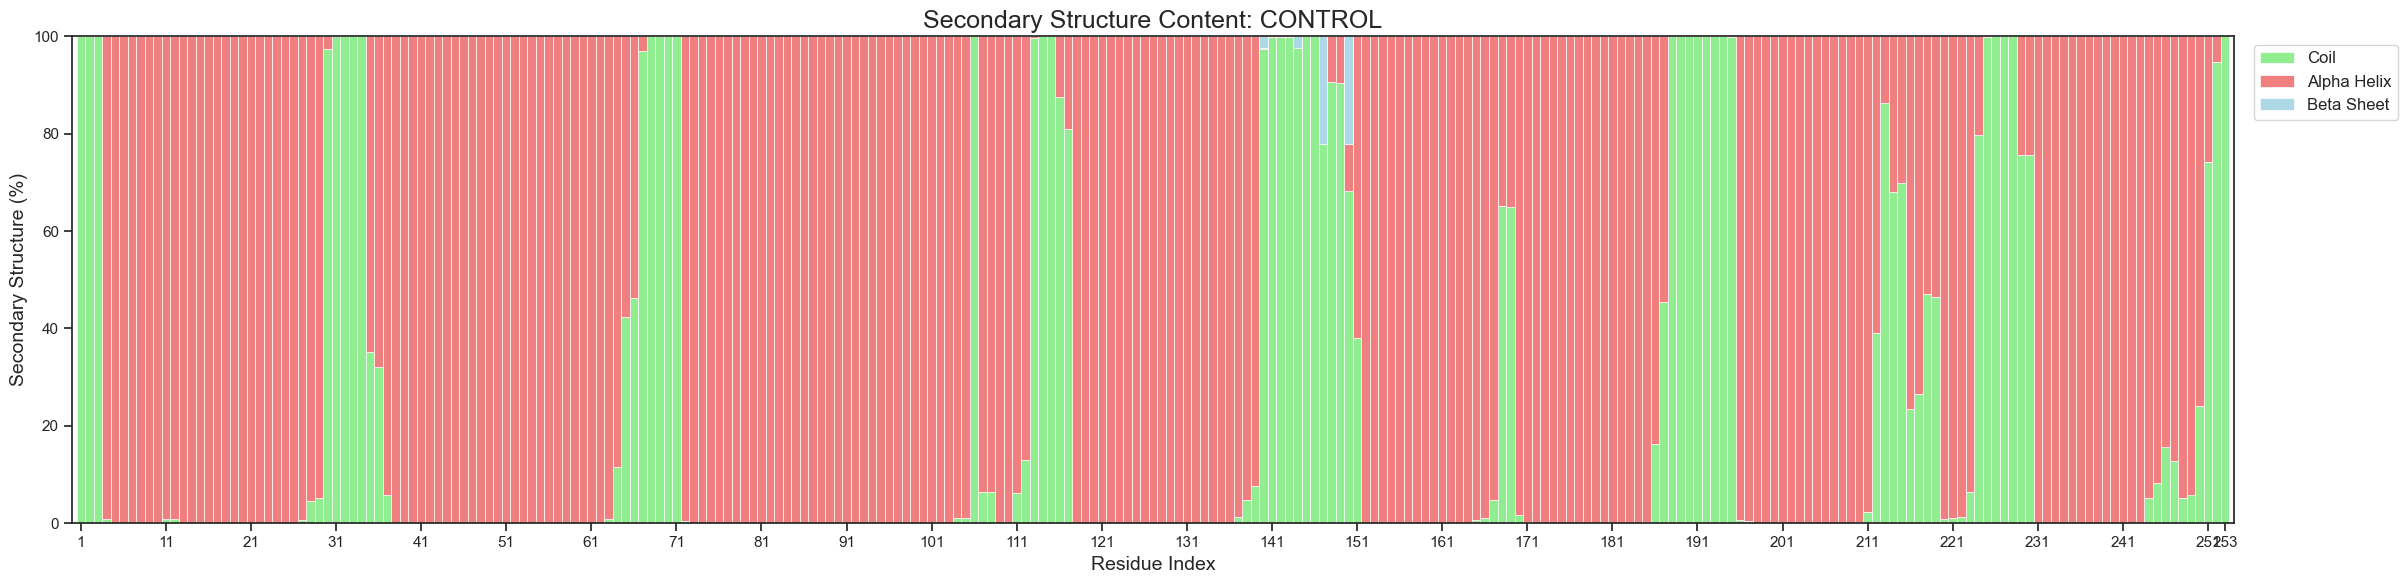


Skipped ligand visualization (CONTROL system run or data not found).


In [54]:
# Cell 9: Visualize Secondary Structure Stacked Bar Chart

sns.set_theme(style="ticks")

# Define uniform colors
color_coil = 'lightgreen'
color_helix = 'lightcoral'
color_sheet = 'lightblue'

# ==========================================
# PLOT 1: ISOLATED PROTEIN
# ==========================================
df_plot = df_ss_protein

# 1. Initialize the plot canvas
fig1, ax1 = plt.subplots(figsize=(24, 6))

# 2. Plot the stacked bars
ax1.bar(df_plot.index, df_plot['Coil_%'], label='Coil', 
        color=color_coil, width=1.0, edgecolor='white', linewidth=0.5)

ax1.bar(df_plot.index, df_plot['Helix_%'], bottom=df_plot['Coil_%'], 
        label='Alpha Helix', color=color_helix, width=1.0, edgecolor='white', linewidth=0.5)

ax1.bar(df_plot.index, df_plot['Sheet_%'], bottom=df_plot['Coil_%'] + df_plot['Helix_%'], 
        label='Beta Sheet', color=color_sheet, width=1.0, edgecolor='white', linewidth=0.5)

# 3. Formatting and Aesthetics
ax1.set_xlabel('Residue Index', fontsize=14)
ax1.set_ylabel('Secondary Structure (%)', fontsize=14)
ax1.set_title(f'Secondary Structure Content: {system_prefix}', fontsize=18)

ax1.set_xlim(df_plot.index.min() - 1, df_plot.index.max() + 1)
ax1.set_ylim(0, 100)

# --- LABEL FORMATTING (WITH C-TERMINUS FIX) ---
tick_spacing = 10

# Generate a mutable Python list of the standard 10-step grid
tick_positions = list(df_plot.index[::tick_spacing])

# Identify the absolute final residue in the DataFrame
final_residue = df_plot.index[-1]

# If the final residue did not land perfectly on the 10-step grid, append it to the list
if tick_positions[-1] != final_residue:
    tick_positions.append(final_residue)

# Apply the customized list to the X-axis
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_positions, rotation=0, ha='center')

ax1.legend(loc='upper right', bbox_to_anchor=(1.08, 1.0), fontsize=12)
plt.tight_layout()

# Save outputs to root directory
plt.savefig(fn_ss_prot_png, dpi=1200, bbox_inches='tight')
plt.savefig(fn_ss_prot_pdf, bbox_inches='tight')
plt.show()

# ==========================================
# CONDITIONAL PLOT: LIGAND
# ==========================================
if df_ss_ligand is not None:
    df_plot_lig = df_ss_ligand
    
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    
    ax2.bar(df_plot_lig.index, df_plot_lig['Coil_%'], label='Coil', 
            color=color_coil, width=1.0, edgecolor='white', linewidth=0.5)

    ax2.bar(df_plot_lig.index, df_plot_lig['Helix_%'], bottom=df_plot_lig['Coil_%'], 
            label='Alpha Helix', color=color_helix, width=1.0, edgecolor='white', linewidth=0.5)

    ax2.bar(df_plot_lig.index, df_plot_lig['Sheet_%'], bottom=df_plot_lig['Coil_%'] + df_plot_lig['Helix_%'], 
            label='Beta Sheet', color=color_sheet, width=1.0, edgecolor='white', linewidth=0.5)

    ax2.set_xlabel('Ligand Residue Index', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Secondary Structure (%)', fontsize=14, fontweight='bold')
    ax2.set_title(f'Secondary Structure Content: Ligand {system_prefix}', fontsize=18)

    ax2.set_xlim(df_plot_lig.index.min() - 0.5, df_plot_lig.index.max() + 0.5)
    ax2.set_ylim(0, 100)

    # The peptide plot inherently shows every residue, so the final residue is always included
    ax2.set_xticks(df_plot_lig.index)
    ax2.set_xticklabels(df_plot_lig.index, rotation=0, ha='center')

    ax2.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), fontsize=12)
    plt.tight_layout()
    
    # Save outputs to root directory
    plt.savefig(fn_ss_lig_png, dpi=1200, bbox_inches='tight')
    plt.savefig(fn_ss_lig_pdf, bbox_inches='tight')
    plt.show()
else:
    print("\nSkipped ligand visualization (CONTROL system run or data not found).")

In [55]:
# Cell 10: Per-Residue Secondary Structure Classification

def classify_residues(df, threshold=60.0):
    """
    Evaluates each residue's SS percentages against a stability threshold.
    Returns a detailed per-residue DataFrame with the classifications appended.
    """
    # Create a copy so we do not mutate the original data in memory
    res_df = df.copy()
    
    # 1. Isolate the numerical columns to perform math on them
    ss_cols = ['Helix_%', 'Sheet_%', 'Coil_%']
    ss_data = res_df[ss_cols]
    
    # 2. Vectorized Extraction
    # idxmax(axis=1) grabs the column name (e.g., 'Helix_%') with the highest value
    dominant_raw = ss_data.idxmax(axis=1)
    max_vals = ss_data.max(axis=1)
    
    # Map the raw column headers to clean scientific labels
    ss_map = {'Helix_%': 'Alpha Helix', 'Sheet_%': 'Beta Sheet', 'Coil_%': 'Coil'}
    
    # 3. Apply the threshold logic row by row
    classifications = []
    for col, val in zip(dominant_raw, max_vals):
        if val >= threshold:
            classifications.append(ss_map[col])
        else:
            classifications.append('Mixed')
            
    # 4. Append the new data as columns to our detailed DataFrame
    res_df['Dominant_SS'] = classifications
    res_df['Confidence_%'] = max_vals.round(2)
    
    return res_df

# 5. Execute for the Receptor (Using a 60% stability threshold)
df_protein_classified = classify_residues(df_ss_protein, threshold=60.0)

# index=True keeps the residue numbers generated in Cell 8
df_protein_classified.to_csv(fn_ss_prot_per_res_csv, index=True)
print(f"Receptor detailed classification saved to: {fn_ss_prot_per_res_csv}")

# 6. Conditionally Execute for the Ligand
if df_ss_ligand is not None:
    df_ligand_classified = classify_residues(df_ss_ligand, threshold=60.0)
    df_ligand_classified.to_csv(fn_ss_lig_per_res_csv, index=True)
    print(f"Ligand detailed classification saved to: {fn_ss_lig_per_res_csv}")
else:
    print("Skipped ligand classification (Control system run or data not found).")

# Display a preview of the Receptor to verify the new columns
display(df_protein_classified.head(15))

Receptor detailed classification saved to: CONTROL_Receptor_SS_Per_Res.csv
Skipped ligand classification (Control system run or data not found).


,Helix_%,Sheet_%,Coil_%,Dominant_SS,Confidence_%
Residue,,,,,
1,0.0,0.0,100.0,Coil,100.0
2,0.0,0.0,100.0,Coil,100.0
3,0.0,0.0,100.0,Coil,100.0
4,99.1,0.0,0.9,Alpha Helix,99.1
5,100.0,0.0,0.0,Alpha Helix,100.0
6,100.0,0.0,0.0,Alpha Helix,100.0
7,100.0,0.0,0.0,Alpha Helix,100.0
8,100.0,0.0,0.0,Alpha Helix,100.0
9,100.0,0.0,0.0,Alpha Helix,100.0


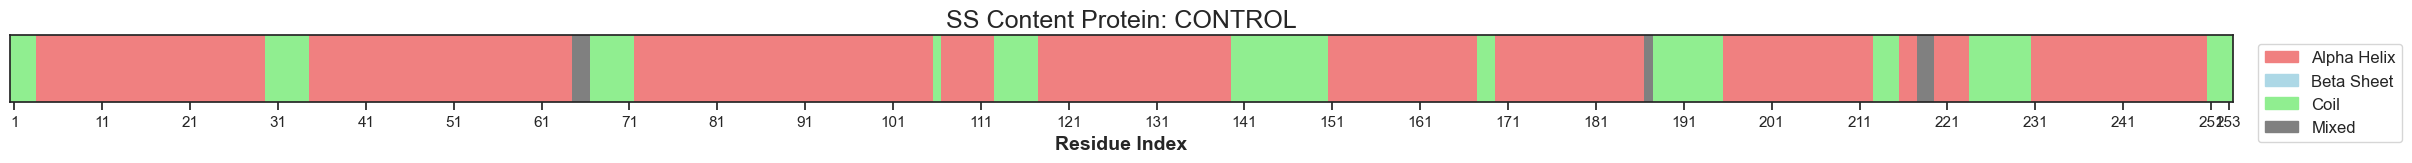

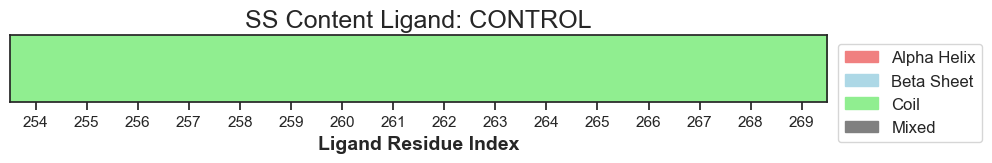

In [56]:
# Cell 11: Visualize Dominant Structure 1D Heatmap

# 1. Setup the Numeric Data Mapping and Colors
ss_levels = {'Mixed': 0, 'Coil': 1, 'Beta Sheet': 2, 'Alpha Helix': 3}
colors = ['gray', 'lightgreen', 'lightblue', 'lightcoral']

custom_cmap = ListedColormap(colors)

legend_patches = [
    mpatches.Patch(color='lightcoral', label='Alpha Helix'),
    mpatches.Patch(color='lightblue', label='Beta Sheet'),
    mpatches.Patch(color='lightgreen', label='Coil'),
    mpatches.Patch(color='gray', label='Mixed')
]

# ==========================================
# PLOT 1: ISOLATED PROTEIN HEATMAP
# ==========================================
df_plot_prot = df_protein_classified
residues_prot = df_plot_prot.index

# Convert classifications to numbers for the heatmap array
y_numeric_prot = df_plot_prot['Dominant_SS'].map(ss_levels).values
heatmap_data_prot = y_numeric_prot.reshape(1, -1)

# Initialize the plot canvas (Height set to 1.8)
fig1, ax1 = plt.subplots(figsize=(24, 1.8))

# Draw the Heatmap
ax1.imshow(heatmap_data_prot, cmap=custom_cmap, aspect='auto', vmin=-0.5, vmax=3.5)

# Formatting the Axes
ax1.set_yticks([]) 

# imshow uses 0-based pixel indexing
x_positions_prot = np.arange(len(residues_prot))
tick_spacing = 10

tick_pos_prot = list(x_positions_prot[::tick_spacing])
tick_labs_prot = list(residues_prot[::tick_spacing])

# Append the final residue if it is missing from the 10-step grid
if tick_pos_prot[-1] != x_positions_prot[-1]:
    tick_pos_prot.append(x_positions_prot[-1])
    tick_labs_prot.append(residues_prot[-1])

ax1.set_xticks(tick_pos_prot)
ax1.set_xticklabels(tick_labs_prot, rotation=0, ha='center')

ax1.set_xlabel('Residue Index', fontsize=14, fontweight='bold')
ax1.set_title(f"SS Content Protein: {system_prefix}", fontsize=18)

ax1.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.08, 1), fontsize=12)

plt.tight_layout()

# Save outputs to root
plt.savefig(fn_ss_prot_heat_png, dpi=1200, bbox_inches='tight')
plt.savefig(fn_ss_prot_heat_pdf, bbox_inches='tight')
plt.show()

# ==========================================
# CONDITIONAL PLOT: LIGAND HEATMAP
# ==========================================
if 'df_ligand_classified' in locals():
    df_plot_lig = df_ligand_classified
    residues_lig = df_plot_lig.index
    
    y_numeric_lig = df_plot_lig['Dominant_SS'].map(ss_levels).values
    heatmap_data_lig = y_numeric_lig.reshape(1, -1)
    
    # Smaller width for the ligand
    fig2, ax2 = plt.subplots(figsize=(10, 1.8))
    
    ax2.imshow(heatmap_data_lig, cmap=custom_cmap, aspect='auto', vmin=-0.5, vmax=3.5)
    
    ax2.set_yticks([]) 
    
    x_positions_lig = np.arange(len(residues_lig))
    
    # Show every residue for the short ligand
    ax2.set_xticks(x_positions_lig)
    ax2.set_xticklabels(residues_lig, rotation=0, ha='center')
    
    ax2.set_xlabel('Ligand Residue Index', fontsize=14, fontweight='bold')
    ax2.set_title(f"SS Content Ligand: {system_prefix}", fontsize=18)
    
    ax2.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.20, 1), fontsize=12)
    
    plt.tight_layout()
    
    # Save outputs to root
    plt.savefig(fn_ss_lig_heat_png, dpi=1200, bbox_inches='tight')
    plt.savefig(fn_ss_lig_heat_pdf, bbox_inches='tight')
    plt.show()
else:
    print("\nSkipped ligand ribbon visualization (Control system run or data not found).")

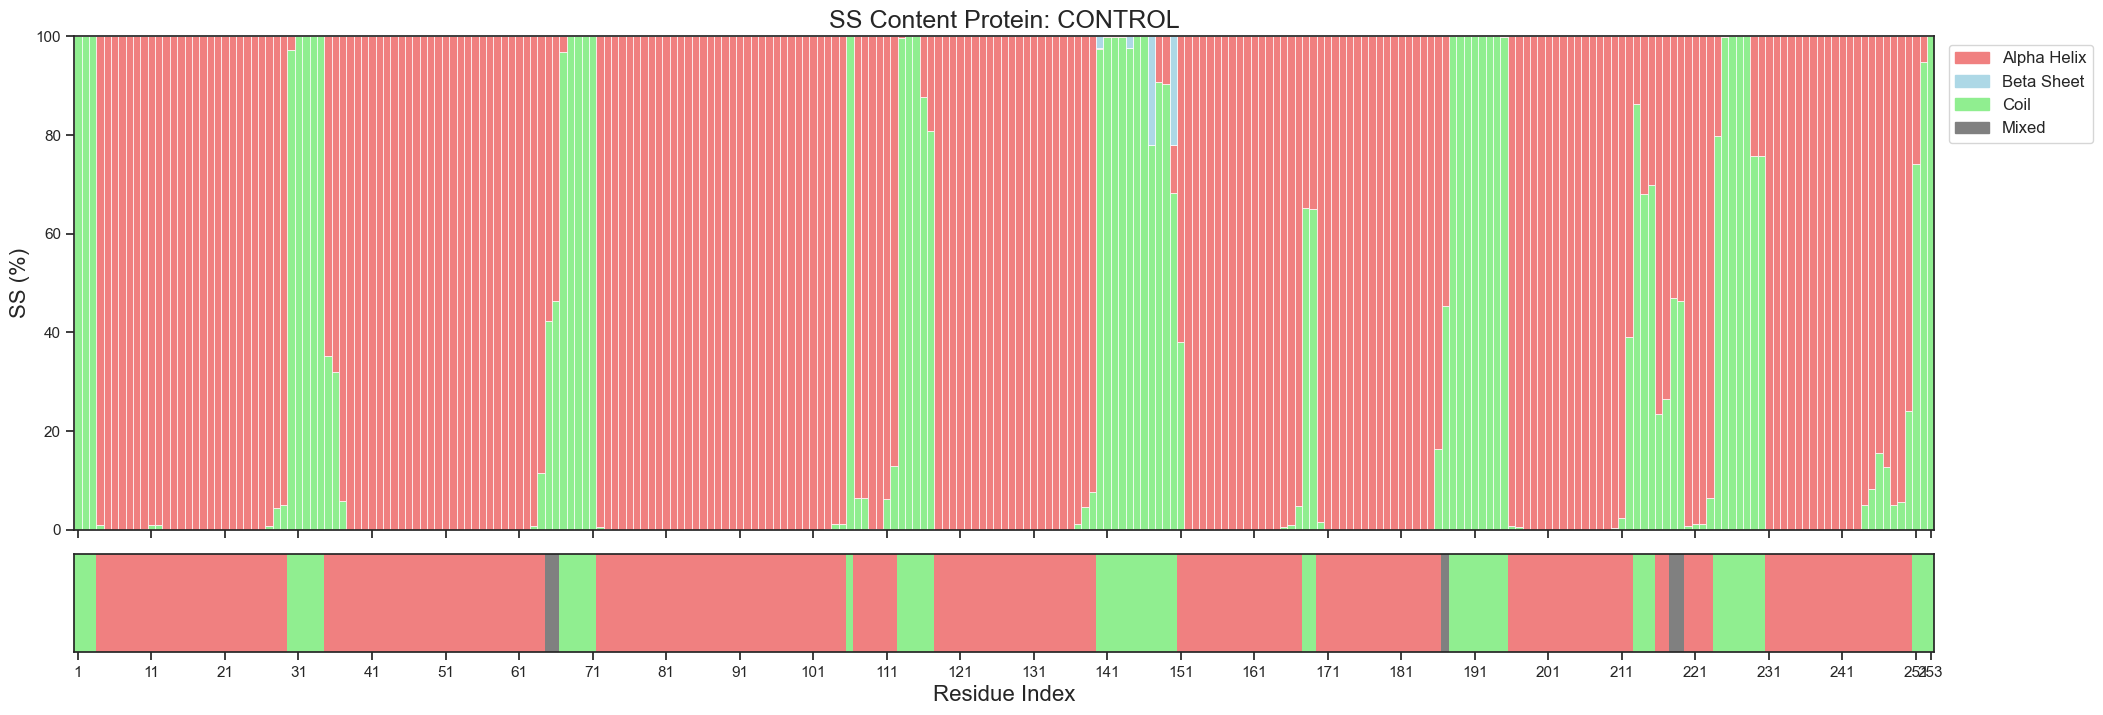

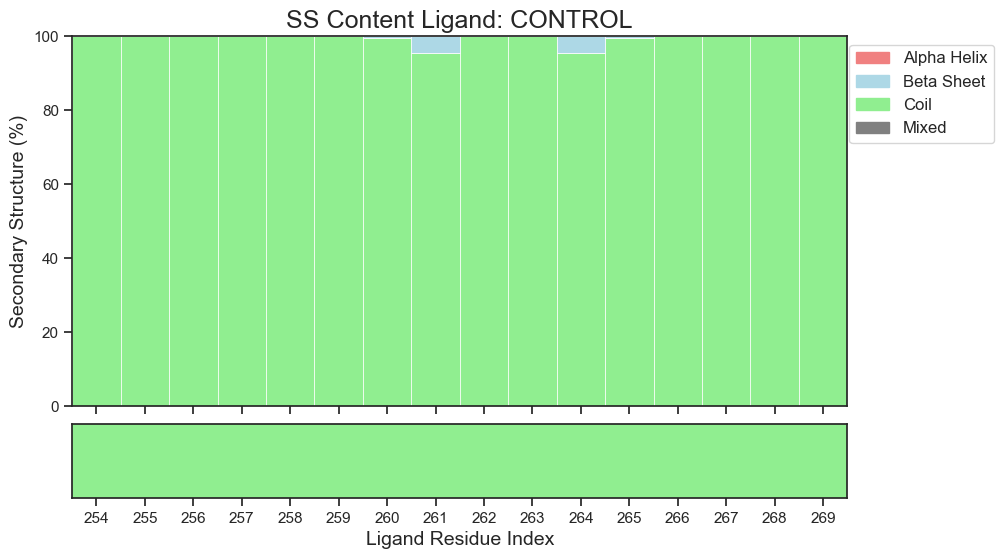

In [57]:
# Cell 12: Visualize Composite Secondary Structure Figure

color_coil = 'lightgreen'
color_helix = 'lightcoral'
color_sheet = 'lightblue'

legend_patches = [
    mpatches.Patch(color='lightcoral', label='Alpha Helix'),
    mpatches.Patch(color='lightblue', label='Beta Sheet'),
    mpatches.Patch(color='lightgreen', label='Coil'),
    mpatches.Patch(color='gray', label='Mixed')
]

ss_levels = {'Mixed': 0, 'Coil': 1, 'Beta Sheet': 2, 'Alpha Helix': 3}
custom_cmap = ListedColormap(['gray', 'lightgreen', 'lightblue', 'lightcoral'])

# ==========================================
# COMPOSITE PLOT 1: RECEPTOR
# ==========================================
df_plot = df_protein_classified

# 1. Initialize the Composite Canvas
fig1, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(24, 8), 
                                gridspec_kw={'height_ratios': [5, 1]}, sharex=True)

# --- TOP SUBPLOT (ax1): Stacked Bar Chart ---
ax1.bar(df_plot.index, df_plot['Coil_%'], color=color_coil, width=1.0, edgecolor='white', linewidth=0.5)
ax1.bar(df_plot.index, df_plot['Helix_%'], bottom=df_plot['Coil_%'], color=color_helix, width=1.0, edgecolor='white', linewidth=0.5)
ax1.bar(df_plot.index, df_plot['Sheet_%'], bottom=df_plot['Coil_%'] + df_plot['Helix_%'], color=color_sheet, width=1.0, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('SS (%)', fontsize=16)
ax1.set_title(f'SS Content Protein: {system_prefix}', fontsize=18)
ax1.set_ylim(0, 100)
ax1.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.09, 1.0), fontsize=12)

# --- BOTTOM SUBPLOT (ax2): 1D Heatmap Ribbon ---
y_numeric = df_plot['Dominant_SS'].map(ss_levels).values
heatmap_data = y_numeric.reshape(1, -1)

# Use extent to perfectly align the heatmap grid with the absolute index of the bar chart
ax2.imshow(heatmap_data, cmap=custom_cmap, aspect='auto', 
           extent=[df_plot.index.min() - 0.5, df_plot.index.max() + 0.5, 0, 1], vmin=-0.5, vmax=3.5)
ax2.set_yticks([]) 

# --- SHARED X-AXIS FORMATTING ---
tick_spacing = 10
tick_pos = list(df_plot.index[::tick_spacing])
tick_labs = list(df_plot.index[::tick_spacing])

if tick_pos[-1] != df_plot.index[-1]:
    tick_pos.append(df_plot.index[-1])
    tick_labs.append(df_plot.index[-1])

ax2.set_xticks(tick_pos)
ax2.set_xticklabels(tick_labs, rotation=0, ha='center')
ax2.set_xlabel('Residue Index', fontsize=16)

ax1.set_xlim(df_plot.index.min() - 0.5, df_plot.index.max() + 0.5)

# Compress the vertical space between the plots
plt.subplots_adjust(hspace=0.08)

# Save outputs to root
plt.savefig(fn_ss_prot_comp_png, dpi=1200, bbox_inches='tight')
plt.savefig(fn_ss_prot_comp_pdf, bbox_inches='tight')
plt.show()

# ==========================================
# COMPOSITE PLOT 2: LIGAND (CONDITIONAL)
# ==========================================
if 'df_ligand_classified' in locals():
    df_plot_lig = df_ligand_classified
    
    fig2, (ax3, ax4) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), 
                                    gridspec_kw={'height_ratios': [5, 1]}, sharex=True)

    ax3.bar(df_plot_lig.index, df_plot_lig['Coil_%'], color=color_coil, width=1.0, edgecolor='white', linewidth=0.5)
    ax3.bar(df_plot_lig.index, df_plot_lig['Helix_%'], bottom=df_plot_lig['Coil_%'], color=color_helix, width=1.0, edgecolor='white', linewidth=0.5)
    ax3.bar(df_plot_lig.index, df_plot_lig['Sheet_%'], bottom=df_plot_lig['Coil_%'] + df_plot_lig['Helix_%'], color=color_sheet, width=1.0, edgecolor='white', linewidth=0.5)

    ax3.set_ylabel('Secondary Structure (%)', fontsize=14)
    ax3.set_title(f'SS Content Ligand: {system_prefix}', fontsize=18)
    ax3.set_ylim(0, 100)
    ax3.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.20, 1.0), fontsize=12)

    y_numeric_lig = df_plot_lig['Dominant_SS'].map(ss_levels).values
    heatmap_data_lig = y_numeric_lig.reshape(1, -1)

    ax4.imshow(heatmap_data_lig, cmap=custom_cmap, aspect='auto', 
               extent=[df_plot_lig.index.min() - 0.5, df_plot_lig.index.max() + 0.5, 0, 1], vmin=-0.5, vmax=3.5)
    ax4.set_yticks([]) 

    ax4.set_xticks(df_plot_lig.index)
    ax4.set_xticklabels(df_plot_lig.index, rotation=0, ha='center')
    ax4.set_xlabel('Ligand Residue Index', fontsize=14)

    ax3.set_xlim(df_plot_lig.index.min() - 0.5, df_plot_lig.index.max() + 0.5)
    
    plt.subplots_adjust(hspace=0.08)
    
    # Save outputs to root
    plt.savefig(fn_ss_lig_comp_png, dpi=1200, bbox_inches='tight')
    plt.savefig(fn_ss_lig_comp_pdf, bbox_inches='tight')
    plt.show()
else:
    print("\nSkipped composite ligand visualization (Control system run or data not found).")

# Interactions: Intra-Molecular Interactions

In [30]:
# Cell 14: Full Trajectory Interaction Analysis (Multicore PLIP-Style Export)

print("Starting multicore ProLIF analysis to generate PLIP-style files...")

tracked_interactions = [
    "VdWContact", "HBDonor", "HBAcceptor", 
    "PiStacking", "EdgeToFace", "FaceToFace", 
    "Anionic", "Cationic", "CationPi"
]

for i, traj_path in enumerate(trajectory_files):
    rep_num = i + 1
    print(f"\nProcessing Replicate {rep_num}: {traj_path}")
    
    # Dynamic Directory Naming 
    out_dir = f"{system_prefix}_Rep{rep_num}_Frames"
    os.makedirs(out_dir, exist_ok=True)
    
    u = mda.Universe(topology_path, traj_path)
    
    # Explicitly restrict to the receptor sequence length identified in 2.9
    protein_ag = u.select_atoms(f"protein and {protein_sel_str}")
    
    fp = plf.Fingerprint(tracked_interactions, vicinity_cutoff=5.0)
    
    # Apply the safe interaction patch
    for name, interaction_func in fp.interactions.items():
        def make_safe_interaction(orig_func):
            def safe_interaction(lig_res, prot_res, **kwargs):
                # Prevent a residue from being evaluated against itself
                if lig_res.resid == prot_res.resid: 
                    return None
                return orig_func(lig_res, prot_res, **kwargs)
            return safe_interaction
        fp.interactions[name] = make_safe_interaction(interaction_func)
        
    fp.run(u.trajectory, lig=protein_ag, prot=protein_ag, n_jobs=4)
    
    df_raw = fp.to_dataframe()
    
    print(f"Calculation complete. Writing {len(df_raw)} frame files to disk...")
    
    for frame_idx in df_raw.index:
        df_frame = df_raw.loc[[frame_idx]]
        
        # Transpose and unstack to match the required PLIP layout
        df_t = df_frame.T
        df_t.columns = ['Contact_Exists']
        df_plip = df_t.unstack(level='interaction', fill_value=False)
        df_plip.columns = df_plip.columns.droplevel(0)
        
        # Save as a formatted CSV with zero-padded frame numbers
        file_name = os.path.join(out_dir, f"Frame_{frame_idx:04d}.csv")
        df_plip.to_csv(file_name)
            
    del u, fp, df_raw
    gc.collect()

print("\nAll frames successfully extracted and saved to disk.")

Starting multicore ProLIF analysis to generate PLIP-style files...

Processing Replicate 1: MAS2/A19/MAS2_A19ri_model_2_prod_r1.nc


  0%|          | 0/1000 [00:00<?, ?it/s]

Calculation complete. Writing 1000 frame files to disk...

Processing Replicate 2: MAS2/A19/MAS2_A19ri_model_2_prod_r2.nc


  0%|          | 0/1000 [00:00<?, ?it/s]

Calculation complete. Writing 1000 frame files to disk...

Processing Replicate 3: MAS2/A19/MAS2_A19ri_model_2_prod_r3.nc


  0%|          | 0/307 [00:00<?, ?it/s]

Calculation complete. Writing 307 frame files to disk...

All frames successfully extracted and saved to disk.


In [31]:
# Cell 15: Aggregate and Parse ProLIF PLIP-Style CSVs

print("Starting memory-safe aggregation of ProLIF interaction frames...")

rep_summaries = []

for i, traj_path in enumerate(trajectory_files):
    rep_num = i + 1
    # Note: Ensure this folder matches how your ProLIF extraction saved the frames
    frame_dir = f"{system_prefix}_Rep{rep_num}_Frames"
    
    if not os.path.exists(frame_dir):
        print(f"Directory {frame_dir} not found. Skipping...")
        continue
        
    csv_files = sorted(glob.glob(os.path.join(frame_dir, "Frame_*.csv")))
    total_frames = len(csv_files)
    
    if total_frames == 0:
        print(f"No CSV files found in {frame_dir}. Skipping...")
        continue
        
    print(f"Processing Replicate {rep_num}: Aggregating {total_frames} frames...")
    
    rep_sum_df = None
    
    for file_path in csv_files:
        df_frame = pd.read_csv(file_path, index_col=[0, 1])
        df_frame = df_frame.astype(int)
        
        if rep_sum_df is None:
            rep_sum_df = df_frame
        else:
            rep_sum_df = rep_sum_df.add(df_frame, fill_value=0)
            
    rep_freq_df = (rep_sum_df / total_frames) * 100
    rep_freq_df['Replicate'] = rep_num
    
    rep_summaries.append(rep_freq_df)
    print(f"Replicate {rep_num} aggregation complete.")

if rep_summaries:
    print("\nCombining all replicates into the master interaction matrix...")
    df_all_reps = pd.concat(rep_summaries)
    
    df_avg = df_all_reps.drop(columns=['Replicate']).groupby(['ligand', 'protein']).mean()
    df_std = df_all_reps.drop(columns=['Replicate']).groupby(['ligand', 'protein']).std()
    
    df_avg = df_avg.add_suffix('_Avg_%')
    df_std = df_std.add_suffix('_Std_%')
    
    df_final = pd.concat([df_avg, df_std], axis=1).fillna(0.0)
    df_final.index.names = ['Receptor_Residue_1', 'Receptor_Residue_2']
    
    # --- UPDATED: Global Variable ---
    df_final.to_csv(fn_intra_csv)
    print(f"Master interaction matrix safely saved to {fn_intra_csv}")
    
    display(df_final.head(10))
else:
    print("No data was parsed. Ensure the ProLIF extraction loop has completed generating the CSV files.")

Starting memory-safe aggregation of ProLIF interaction frames...
Processing Replicate 1: Aggregating 1000 frames...
Replicate 1 aggregation complete.
Processing Replicate 2: Aggregating 1000 frames...
Replicate 2 aggregation complete.
Processing Replicate 3: Aggregating 307 frames...
Replicate 3 aggregation complete.

Combining all replicates into the master interaction matrix...
Master interaction matrix safely saved to A19_Intramolecular_Interactions.csv


Anionic_Avg_%  CationPi_Avg_%  \
Receptor_Residue_1 Receptor_Residue_2                                  
ALA120.0           ALA124.0                      0.0             0.0   
                   CYS123.0                      0.0             0.0   
                   GLN118.0                      0.0             0.0   
                   LEU121.0                      0.0             0.0   
                   LYS116.0                      0.0             0.0   
                   SER119.0                      0.0             0.0   
                   TYR117.0                      0.0             0.0   
                   VAL122.0                      0.0             0.0   
                   VAL38.0                       0.0             0.0   
ALA124.0           ALA120.0                      0.0             0.0   

                                       Cationic_Avg_%  EdgeToFace_Avg_%  \
Receptor_Residue_1 Receptor_Residue_2                                     
ALA120.0           ALA124.0                       0.0               0.0   
                   CYS123.0                       0.0               0.0   
                   GLN118.0                       0.0               0.0   
                   LEU121.0                       0.0               0.0   
                   LYS116.0                       0.0               0.0   
                   SER119.0                       0.0               0.0   
                   TYR117.0                       0.0               0.0   
                   VAL122.0                       0.0               0.0   
                   VAL38.0                        0.0               0.0   
ALA124.0           ALA120.0                       0.0               0.0   

                                       FaceToFace_Avg_%  HBAcceptor_Avg_%  \
Receptor_Residue_1 Receptor_Residue_2                                       
ALA120.0           ALA124.0                         0.0         97.431379   
                   CYS123.0                         0.0          0.275244   
                   GLN118.0                         0.0          0.000000   
                   LEU121.0                         0.0          0.000000   
                   LYS116.0                         0.0          0.000000   
                   SER119.0                         0.0          0.000000   
                   TYR117.0                         0.0          0.000000   
                   VAL122.0                         0.0          0.000000   
                   VAL38.0                          0.0          0.000000   
ALA124.0           ALA120.0                         0.0          0.000000   

                                       HBDonor_Avg_%  PiStacking_Avg_%  \
Receptor_Residue_1 Receptor_Residue_2                                    
ALA120.0           ALA124.0                 0.000000               0.0   
                   CYS123.0                 0.000000               0.0   
                   GLN118.0                 0.000000               0.0   
                   LEU121.0                 0.000000               0.0   
                   LYS116.0                 0.200000               0.0   
                   SER119.0                 0.033333               0.0   
                   TYR117.0                 2.926710               0.0   
                   VAL122.0                 0.000000               0.0   
                   VAL38.0                  0.000000               0.0   
ALA124.0           ALA120.0                97.431379               0.0   

                                       VdWContact_Avg_%  Anionic_Std_%  \
Receptor_Residue_1 Receptor_Residue_2                                    
ALA120.0           ALA124.0                   98.990445            0.0   
                   CYS123.0                   26.294028            0.0   
                   GLN118.0                   15.361238            0.0   
                   LEU121.0                  100.000000            0.0   
               

In [32]:
# Cell 16: Extract Top Interactions AND Detailed Edge List (Multi-System)
import pandas as pd
import os

print(f"Loading intramolecular interactions from: {fn_intra_csv}...")

# --- 1. Master Domain Dictionaries ---
domain_ranges_at1r = {
    'N-Term': (1, 14), 'TM1': (15, 45), 'ICL1': (46, 51), 'TM2': (52, 79),
    'ECL1': (80, 87), 'TM3': (88, 121), 'ICL2': (122, 131), 'TM4': (132, 156),
    'ECL2': (157, 179), 'TM5': (180, 219), 'ICL3': (220, 226), 'TM6': (227, 257),
    'ECL3': (258, 263), 'TM7': (264, 291), 'Helix8': (292, 308), 'C-Term': (309, 310)
}

domain_ranges_at2r = {
    'N-Term': (1, 6), 'TM1': (7, 37), 'ICL1': (38, 43), 'TM2': (44, 71),
    'ECL1': (72, 78), 'TM3': (79, 113), 'ICL2': (114, 122), 'TM4': (123, 147),
    'ECL2': (148, 166), 'TM5': (167, 207), 'ICL3': (208, 213), 'TM6': (214, 250),
    'ECL3': (251, 255), 'TM7': (256, 278), 'Turn/H8a': (279, 290), 'Helix8': (291, 300),
    'C-Term': (301, 306)
}

domain_ranges_mas1 = {
    'N-Term': (1, 3), 'TM1': (4, 31), 'ICL1': (32, 34), 'TM2': (35, 66),
    'ECL1': (67, 71), 'TM3': (72, 105), 'ICL2': (106, 117), 'TM4': (118, 139),
    'ECL2': (140, 150), 'TM5': (151, 187), 'ICL3': (188, 195), 'TM6': (196, 213),
    'ECL3': (214, 228), 'TM7': (229, 251), 'C-Term': (252, 253)
}

# --- 2. Dynamic System Selection ---
if "AT2R" in system.upper():
    active_domain_ranges = domain_ranges_at2r
    print(" -> AT2R detected. Loading AT2R domain boundaries.")
elif "MAS" in system.upper(): # Catches "MAS1" or "MAS2"
    active_domain_ranges = domain_ranges_mas1
    print(" -> MAS detected. Loading MAS1 domain boundaries.")
elif "AT1R" in system.upper():
    active_domain_ranges = domain_ranges_at1r
    print(" -> AT1R detected. Loading AT1R domain boundaries.")
else:
    print(f" -> WARNING: '{systemid}' not explicitly recognized. Defaulting to AT1R.")
    active_domain_ranges = domain_ranges_at1r

# Pre-compute a direct mapping dictionary for C-level Pandas vectorization
domain_map = {res: dom for dom, (start, end) in active_domain_ranges.items() for res in range(start, end + 1)}
# ------------------------------------------------------

if not os.path.exists(fn_intra_csv):
    print(f"Error: {fn_intra_csv} not found. Check your directory or filename.")
else:
    df_final = pd.read_csv(fn_intra_csv)
    
    if 'Receptor_Residue_1' not in df_final.columns:
        df_final.reset_index(inplace=True)
        
    # --- 1. CLEANUP: Remove '.0' artifacts ---
    df_final['Receptor_Residue_1'] = df_final['Receptor_Residue_1'].astype(str).str.replace(r'\.0$', '', regex=True)
    df_final['Receptor_Residue_2'] = df_final['Receptor_Residue_2'].astype(str).str.replace(r'\.0$', '', regex=True)
    
    # --- 2. FORMAT: Insert Hyphen (e.g., TYR292 -> TYR-292) ---
    df_final['Receptor_Residue_1'] = df_final['Receptor_Residue_1'].str.replace(r'([A-Za-z]+)(\d+)', r'\1-\2', regex=True)
    df_final['Receptor_Residue_2'] = df_final['Receptor_Residue_2'].str.replace(r'([A-Za-z]+)(\d+)', r'\1-\2', regex=True)
    
    interaction_cols = [col for col in df_final.columns if '_Avg_%' in col]
    
    # --- PART 1: The Macro-Summary ---
    df_final['Total_Avg_Freq_%'] = df_final[interaction_cols].sum(axis=1)
    df_top_interactions = df_final.sort_values(by='Total_Avg_Freq_%', ascending=False)
    
    # --- PART 2: Melting the Data for Cytoscape Networks ---
    print("Melting data to extract individual interaction types for Cytoscape...")
    
    df_melted = pd.melt(
        df_final,
        id_vars=['Receptor_Residue_1', 'Receptor_Residue_2'],
        value_vars=interaction_cols,
        var_name='Interaction_Type',
        value_name='Frequency_%'
    )
    
    df_melted['Interaction_Type'] = df_melted['Interaction_Type'].str.replace('_Avg_%', '', regex=False)
    df_detailed_edges = df_melted[df_melted['Frequency_%'] > 0.0].copy()
    
    # --- Assign Domains AND Keep the Pure Numbers ---
    print("Extracting pure numerical IDs and assigning topological domains...")
    df_detailed_edges['Res1_Num'] = df_detailed_edges['Receptor_Residue_1'].astype(str).str.extract(r'(\d+)').astype(float)
    df_detailed_edges['Res2_Num'] = df_detailed_edges['Receptor_Residue_2'].astype(str).str.extract(r'(\d+)').astype(float)
    
    # Vectorized Domain Assignment (replaces slow .apply)
    df_detailed_edges['Domain_1'] = df_detailed_edges['Res1_Num'].map(domain_map).fillna("Unknown")
    df_detailed_edges['Domain_2'] = df_detailed_edges['Res2_Num'].map(domain_map).fillna("Unknown")
    
    # Convert to clean integers
    df_detailed_edges['Res1_Num'] = df_detailed_edges['Res1_Num'].fillna(0).astype(int)
    df_detailed_edges['Res2_Num'] = df_detailed_edges['Res2_Num'].fillna(0).astype(int)
    
    # --- 3. CYTOSCAPE CLOCKWISE FIX: Invert the numbers ---
    df_detailed_edges['Res1_Num_Rev'] = df_detailed_edges['Res1_Num'] * -1
    df_detailed_edges['Res2_Num_Rev'] = df_detailed_edges['Res2_Num'] * -1
    # --------------------------------------------------
    
    df_detailed_edges.sort_values(by='Frequency_%', ascending=False, inplace=True)
    
    # Save using the global variable
    df_detailed_edges.to_csv(fn_intra_detailed_csv, index=False)
    
    print(f"\nDetailed Edge List successfully saved to: {fn_intra_detailed_csv}")
    print("Preview of the new melted structure (with reverse numbers):")
    display(df_detailed_edges.head(10))

Loading intramolecular interactions from: A19_Intramolecular_Interactions.csv...
 -> MAS detected. Loading MAS1 domain boundaries.
Melting data to extract individual interaction types for Cytoscape...
Extracting pure numerical IDs and assigning topological domains...

Detailed Edge List successfully saved to: A19_Detailed_Intra_Edges.csv
Preview of the new melted structure (with reverse numbers):


,Receptor_Residue_1,Receptor_Residue_2,Interaction_Type,Frequency_%,Res1_Num,Res2_Num,Domain_1,Domain_2,Res1_Num_Rev,Res2_Num_Rev
571,GLU-99,ARG-114,Anionic,100.0,99,114,TM3,ICL2,-99,-114
26116,VAL-98,SER-97,VdWContact,100.0,98,97,TM3,TM3,-98,-97
26095,VAL-8,TRP-7,VdWContact,100.0,8,7,TM1,TM1,-8,-7
26110,VAL-98,GLU-99,VdWContact,100.0,98,99,TM3,TM3,-98,-99
26091,VAL-8,ILE-9,VdWContact,100.0,8,9,TM1,TM1,-8,-9
26101,VAL-80,SER-79,VdWContact,100.0,80,79,TM3,TM3,-80,-79
26083,VAL-76,THR-77,VdWContact,100.0,76,77,TM3,TM3,-76,-77
26079,VAL-76,ILE-75,VdWContact,100.0,76,75,TM3,TM3,-76,-75
5947,ARG-114,GLU-99,Cationic,100.0,114,99,ICL2,TM3,-114,-99
19461,SER-176,LEU-172,HBDonor,100.0,176,172,TM5,TM5,-176,-172


# Interaction Visualization

In [35]:
# Cell 21: Isolate, Deduplicate, and Filter Top ProLIF Interactions
import pandas as pd
import numpy as np

# --- UPDATED: Global Variable ---
print(f"Loading {fn_intra_csv} and melting matrix...")

df_prolif = pd.read_csv(fn_intra_csv, index_col=[0, 1])
df_prolif.index.names = ['Residue_1', 'Residue_2']
df_reset = df_prolif.reset_index()

df_reset['Residue_1'] = df_reset['Residue_1'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
df_reset['Residue_2'] = df_reset['Residue_2'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)

df_melted = df_reset.melt(
    id_vars=['Residue_1', 'Residue_2'], 
    var_name='Interaction_Type', 
    value_name='Frequency_%'
)

df_active = df_melted[df_melted['Frequency_%'] > 0.0].copy()

print("Removing bidirectional duplicates...")
df_active['Sorted_Pair'] = df_active.apply(
    lambda row: tuple(sorted([row['Residue_1'], row['Residue_2']])), axis=1
)

df_unique = df_active.drop_duplicates(subset=['Sorted_Pair', 'Interaction_Type']).copy()

print("Filtering out local sequence neighbors (Distance <= 4)...")
df_unique['Sequence_Distance'] = abs(df_unique['Residue_1'] - df_unique['Residue_2'])
df_tertiary = df_unique[df_unique['Sequence_Distance'] > 4]

df_sorted = df_tertiary.sort_values(by='Frequency_%', ascending=False).reset_index(drop=True)

display_cols = ['Residue_1', 'Residue_2', 'Interaction_Type', 'Frequency_%']
print(f"\nTop 20 Long-Distance Structural Anchors detected by ProLIF ({system_prefix}):")
display(df_sorted[display_cols].head(20))

Loading A19_Intramolecular_Interactions.csv and melting matrix...
Removing bidirectional duplicates...
Filtering out local sequence neighbors (Distance <= 4)...

Top 20 Long-Distance Structural Anchors detected by ProLIF (A19):


,Residue_1,Residue_2,Interaction_Type,Frequency_%
0,130,115,Cationic_Avg_%,100.000000
1,160,169,VdWContact_Avg_%,100.000000
2,170,91,VdWContact_Avg_%,100.000000
3,190,195,VdWContact_Avg_%,100.000000
4,264,8,VdWContact_Avg_%,100.000000
5,130,115,VdWContact_Avg_%,100.000000
6,130,115,HBDonor_Avg_%,100.000000
7,115,130,Anionic_Avg_%,100.000000
8,115,130,HBAcceptor_Avg_%,100.000000
9,191,196,VdWContact_Avg_%,99.932796


In [13]:
# Cell 21: Path Definitions
# Pointing to the specific AMBER simulation files
amber_topology = "AT1R/A18/AT1R_A18_model_1.prmtop"
amber_trajectory = "AT1R/A18/AT1R_A18_model_1_prod_r1.nc"

In [14]:
# Cell 22: Automated Scan with Explicit Text-Based Legend
import os
import MDAnalysis as mda
import prolif as plf
import py3Dmol
from prolif.plotting.complex3d import Complex3D

# 1. Update ProLIF's global color dictionary for 3D plotting
Complex3D.COLORS.update({
    'Hydrophobic': 'purple',
    'VdWContact': 'green',
    'HBDonor': 'blue',
    'HBAcceptor': 'red',
    'PiStacking': 'orange',
    'Disulfide': 'gold',
    'Cationic': 'cyan',
    'Anionic': 'magenta'
})

rank_index = 0 

res1 = int(df_sorted.iloc[rank_index]['Residue_1'])
res2 = int(df_sorted.iloc[rank_index]['Residue_2'])
interaction_type = df_sorted.iloc[rank_index]['Interaction_Type']
frequency = df_sorted.iloc[rank_index]['Frequency_%']

print(f"Targeting Rank #{rank_index + 1} Interaction:")
print(f"Residue {res1} to Residue {res2} | Main Type: {interaction_type} | Freq: {frequency}%\n")

# Use the dynamic variables established at the start of the notebook
amber_topology = topology_path
amber_trajectory = trajectory_files[0] 

u = mda.Universe(amber_topology, amber_trajectory)

ligand_selection = u.select_atoms(f"resid {res1}")
protein_selection = u.select_atoms(f"resid {res2}")

fp = plf.Fingerprint()
fp.run(u.trajectory, ligand_selection, protein_selection)

df = fp.to_dataframe()
active_frames = df.dropna(how='all').index

if len(active_frames) > 0:
    target_frame = active_frames[0]
    frame_interactions = df.loc[target_frame].dropna().index.get_level_values('interaction').unique().tolist()
    
    # 2. Build and print the text-based legend explicitly ABOVE the visualizer
    print(f"Success! Interaction detected at Frame {target_frame}.\n")
    print("=== INTERACTION LEGEND ===")
    for ix in frame_interactions:
        color_name = Complex3D.COLORS.get(ix, 'gray').upper()
        print(f"• {ix}: {color_name} dashed line")
    print("==========================\n")

    u.trajectory[target_frame]
    full_protein = u.select_atoms("protein")
    u.atoms.translate(-full_protein.center_of_mass())
    
    com1 = ligand_selection.center_of_mass()
    com2 = protein_selection.center_of_mass()
    resname1 = ligand_selection.resnames[0]
    resname2 = protein_selection.resnames[0]
    
    lig_mol = plf.Molecule.from_mda(ligand_selection)
    prot_mol = plf.Molecule.from_mda(protein_selection)
    
    # 3. Generate the base ProLIF view
    view = fp.plot_3d(
        lig_mol, 
        prot_mol, 
        frame=target_frame, 
        display_all=False
    )
    
    # Inject Residue Labels (Pinned to the atoms, so they rotate cleanly)
    view.addLabel(f"{resname1} {res1}", 
                  {'position': {'x': com1[0], 'y': com1[1], 'z': com1[2]}, 
                   'backgroundColor': 'black', 'fontColor': 'white', 'backgroundOpacity': 0.7, 'fontSize': 14})
    
    view.addLabel(f"{resname2} {res2}", 
                  {'position': {'x': com2[0], 'y': com2[1], 'z': com2[2]}, 
                   'backgroundColor': 'black', 'fontColor': 'white', 'backgroundOpacity': 0.7, 'fontSize': 14})
    
    # 4. Inject the full protein backbone
    temp_pdb = "temp_background.pdb"
    full_protein.write(temp_pdb)
    
    with open(temp_pdb, 'r') as f:
        full_pdb_data = f.read()
        
    view.addModel(full_pdb_data, 'pdb')
    view.setStyle({'model': -1}, {'cartoon': {'color': 'lightgray', 'opacity': 0.4}})
    view.zoomTo({'resi': [res1, res2]})
    
    if os.path.exists(temp_pdb):
        os.remove(temp_pdb)
        
    view.show()
    
else:
    print(f"No non-covalent interactions detected between Residue {res1} and {res2} in this trajectory.")

Targeting Rank #1 Interaction:
Residue 264 to Residue 8 | Main Type: VdWContact_Avg_% | Freq: 100.0%



  0%|          | 0/905 [00:00<?, ?it/s]

Success! Interaction detected at Frame 0.

=== INTERACTION LEGEND ===
• Hydrophobic: PURPLE dashed line
• VdWContact: GREEN dashed line



/home/sfuentes/miniconda3/envs/MDAnalysis/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/sfuentes/miniconda3/envs/MDAnalysis/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/sfuentes/miniconda3/envs/MDAnalysis/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn("Found no information for attr: '{}'"
/home/sfuentes/miniconda3/envs/MDAnalysis/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/home/sfuentes/miniconda3/e

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Interactions: Inter-molecular Interactions

In [33]:
# Cell 23: Intermolecular Trajectory Analysis (Protein-Ligand)

# Safely check if a ligand exists before doing heavy compute
if not has_ligand:
    print("No ligand detected in this system.")
else:
    protein_selection = f"protein and {protein_sel_str}"
    ligand_selection = ligand_sel_str

    print("Starting ProLIF")

    tracked_interactions = [
        "VdWContact", "HBDonor", "HBAcceptor", 
        "PiStacking", "EdgeToFace", "FaceToFace", 
        "Anionic", "Cationic", "CationPi"
    ]

    for i, traj_path in enumerate(trajectory_files):
        rep_num = i + 1
        print(f"\nProcessing Replicate {rep_num}: {traj_path}")
        
        # Create a distinct directory for intermolecular frames
        out_dir = f"{system_prefix}_Inter_Rep{rep_num}_Frames"
        os.makedirs(out_dir, exist_ok=True)
        
        u = mda.Universe(topology_path, traj_path)
        
        # Isolate the two separate entities using our dynamic masks
        protein_ag = u.select_atoms(protein_selection)
        ligand_ag = u.select_atoms(ligand_selection)
        
        fp = plf.Fingerprint(tracked_interactions, vicinity_cutoff=5.0)
        fp.run(u.trajectory, lig=ligand_ag, prot=protein_ag, n_jobs=4)
        
        df_raw = fp.to_dataframe()
        
        print(f"Calculation complete. Writing {len(df_raw)}")
        
        for frame_idx in df_raw.index:
            df_frame = df_raw.loc[[frame_idx]]
            
            # Transpose and unstack to match the required PLIP layout
            df_t = df_frame.T
            df_t.columns = ['Contact_Exists']
            df_plip = df_t.unstack(level='interaction', fill_value=False)
            df_plip.columns = df_plip.columns.droplevel(0)
            
            file_name = os.path.join(out_dir, f"Frame_{frame_idx:04d}.csv")
            df_plip.to_csv(file_name)
                
        del u, fp, df_raw
        gc.collect()

    print("\nDone")

Starting ProLIF

Processing Replicate 1: MAS2/A19/MAS2_A19ri_model_2_prod_r1.nc


  0%|          | 0/1000 [00:00<?, ?it/s]

Calculation complete. Writing 1000

Processing Replicate 2: MAS2/A19/MAS2_A19ri_model_2_prod_r2.nc


  0%|          | 0/1000 [00:00<?, ?it/s]

Calculation complete. Writing 1000

Processing Replicate 3: MAS2/A19/MAS2_A19ri_model_2_prod_r3.nc


  0%|          | 0/307 [00:00<?, ?it/s]

Calculation complete. Writing 307

Done


In [34]:
# Cell 24: Aggregate and Parse Intermolecular CSVs
print(f"Starting memory-safe aggregation of Intermolecular frames for {system_prefix}...")

rep_summaries = []

for i, traj_path in enumerate(trajectory_files):
    rep_num = i + 1
    # Generalized directory naming
    frame_dir = f"{system_prefix}_Inter_Rep{rep_num}_Frames"
    
    if not os.path.exists(frame_dir):
        print(f"Directory {frame_dir} not found. Skipping...")
        continue
        
    csv_files = sorted(glob.glob(os.path.join(frame_dir, "Frame_*.csv")))
    total_frames = len(csv_files)
    
    if total_frames == 0:
        print(f"No CSV files found in {frame_dir}. Skipping...")
        continue
        
    print(f"Processing Replicate {rep_num}: Aggregating {total_frames} frames...")
    
    rep_sum_df = None
    
    for file_path in csv_files:
        df_frame = pd.read_csv(file_path, index_col=[0, 1])
        df_frame = df_frame.astype(int)
        
        if rep_sum_df is None:
            rep_sum_df = df_frame
        else:
            rep_sum_df = rep_sum_df.add(df_frame, fill_value=0)
            
    rep_freq_df = (rep_sum_df / total_frames) * 100
    rep_freq_df['Replicate'] = rep_num
    
    rep_summaries.append(rep_freq_df)
    print(f"Replicate {rep_num} aggregation complete.")

if rep_summaries:
    print("\nCombining all replicates into the master interaction matrix...")
    df_all_reps = pd.concat(rep_summaries)
    
    df_avg = df_all_reps.drop(columns=['Replicate']).groupby(['ligand', 'protein']).mean()
    df_std = df_all_reps.drop(columns=['Replicate']).groupby(['ligand', 'protein']).std()
    
    df_avg = df_avg.add_suffix('_Avg_%')
    df_std = df_std.add_suffix('_Std_%')
    
    df_final_inter = pd.concat([df_avg, df_std], axis=1).fillna(0.0)
    
    # Rename the index to be mathematically precise about what is binding to what
    df_final_inter.index.names = ['Ligand_Residue', 'Receptor_Residue']
    df_final_inter.to_csv(fn_inter_csv)
    print(f"Master intermolecular matrix safely saved to {fn_inter_csv}")
    
    display(df_final_inter.head(10))
else:
    print("No data was parsed. Ensure the ProLIF extraction loop has completed.")

Starting memory-safe aggregation of Intermolecular frames for A19...
Processing Replicate 1: Aggregating 1000 frames...
Replicate 1 aggregation complete.
Processing Replicate 2: Aggregating 1000 frames...
Replicate 2 aggregation complete.
Processing Replicate 3: Aggregating 307 frames...
Replicate 3 aggregation complete.

Combining all replicates into the master interaction matrix...
Master intermolecular matrix safely saved to A19_Intermolecular_Interactions.csv


VdWContact_Avg_%  PiStacking_Avg_%  \
Ligand_Residue Receptor_Residue                                       
ARG261.0       ASP60.0                   0.000000               0.0   
               ASP64.0                  11.074919               0.0   
               GLY229.0                  1.954397               0.0   
               HID232.0                 64.277090               0.0   
               HID233.0                 12.210586               0.0   
               HID6.0                    0.100000               0.0   
               ILE75.0                   4.816395               0.0   
               LEU236.0                  2.441911               0.0   
               LEU57.0                   8.843865               0.0   
               LEU83.0                   1.208578               0.0   

                                 EdgeToFace_Avg_%  HBDonor_Avg_%  \
Ligand_Residue Receptor_Residue                                    
ARG261.0       ASP60.0                        0.0       0.000000   
               ASP64.0                        0.0      11.400651   
               GLY229.0                       0.0       0.000000   
               HID232.0                       0.0      52.213681   
               HID233.0                       0.0      10.657655   
               HID6.0                         0.0       0.000000   
               ILE75.0                        0.0       0.000000   
               LEU236.0                       0.0       0.000000   
               LEU57.0                        0.0       0.000000   
               LEU83.0                        0.0       0.000000   

                                 HBAcceptor_Avg_%  FaceToFace_Avg_%  \
Ligand_Residue Receptor_Residue                                       
ARG261.0       ASP60.0                        0.0               0.0   
               ASP64.0                        0.0               0.0   
               GLY229.0                       0.0               0.0   
               HID232.0                       0.0               0.0   
               HID233.0                       0.0               0.0   
               HID6.0                         0.0               0.0   
               ILE75.0                        0.0               0.0   
               LEU236.0                       0.0               0.0   
               LEU57.0                        0.0               0.0   
               LEU83.0                        0.0               0.0   

                                 Anionic_Avg_%  CationPi_Avg_%  \
Ligand_Residue Receptor_Residue                                  
ARG261.0       ASP60.0                     0.0             0.0   
               ASP64.0                     0.0             0.0   
               GLY229.0                    0.0             0.0   
               HID232.0                    0.0             0.0   
               HID233.0                    0.0             0.0   
               HID6.0                      0.0             0.0   
               ILE75.0                     0.0             0.0   
               LEU236.0                    0.0             0.0   
               LEU57.0                     0.0             0.0   
               LEU83.0                     0.0             0.0   

                                 Cationic_Avg_%  VdWContact_Std_%  \
Ligand_Residue Receptor_Residue                                     
ARG261.0       ASP60.0                 0.325733          0.000000   
               ASP64.0                14.006515          0.000000   
               GLY229.0                0.000000          0.000000   
               HID232.0                0.000000         24.537318   
               HID233.0                0.000000         11.752944   
               HID6.0                  0.000000          0.000000   
               ILE75.0                 0.000000          5.265074   
               LEU236.0                0.000000          1.961799   
               LEU57.0     

In [35]:
# Cell 25: Extract and Rank Top Protein-Ligand Interactions
import os
import pandas as pd

if not os.path.exists(fn_inter_csv):
    print(f"Error: {fn_inter_csv} not found. Ensure the aggregation cell completed.")
else:
    df_inter = pd.read_csv(fn_inter_csv)
    
    if 'Ligand_Residue' not in df_inter.columns:
        df_inter.reset_index(inplace=True)
        
    # --- 1. CLEANUP: Remove '.0' artifacts ---
    df_inter['Ligand_Residue'] = df_inter['Ligand_Residue'].astype(str).str.replace(r'\.0$', '', regex=True)
    df_inter['Receptor_Residue'] = df_inter['Receptor_Residue'].astype(str).str.replace(r'\.0$', '', regex=True)
    
    # --- 2. FORMAT: Insert Hyphen (e.g., TYR292 -> TYR-292) ---
    df_inter['Ligand_Residue'] = df_inter['Ligand_Residue'].str.replace(r'([A-Za-z]+)(\d+)', r'\1-\2', regex=True)
    df_inter['Receptor_Residue'] = df_inter['Receptor_Residue'].str.replace(r'([A-Za-z]+)(\d+)', r'\1-\2', regex=True)
        
    print("Calculating combined binding frequencies...")

    # --- PART 1: The Macro-Summary ---
    interaction_cols = [col for col in df_inter.columns if '_Avg_%' in col]
    df_inter['Total_Avg_Freq_%'] = df_inter[interaction_cols].sum(axis=1)
    df_top_inter = df_inter.sort_values(by='Total_Avg_Freq_%', ascending=False)
    
    print(f"\nTop 20 Strongest Protein-Ligand Anchors ({system_prefix}):")
    display_cols = ['Ligand_Residue', 'Receptor_Residue'] + interaction_cols + ['Total_Avg_Freq_%']
    display(df_top_inter[display_cols].head(20))

    # --- PART 2: Melting the Data for Cytoscape Networks ---
    print("\nMelting data to extract individual interaction types for Cytoscape...")
    
    df_melted_inter = pd.melt(
        df_inter,
        id_vars=['Ligand_Residue', 'Receptor_Residue'],
        value_vars=interaction_cols,
        var_name='Interaction_Type',
        value_name='Frequency_%'
    )
    
    df_melted_inter['Interaction_Type'] = df_melted_inter['Interaction_Type'].str.replace('_Avg_%', '', regex=False)
    df_detailed_inter_edges = df_melted_inter[df_melted_inter['Frequency_%'] > 0.0].copy()
    
    # Check if the assign_domain function exists from Cell 16, if not, define a fallback
    if 'assign_domain' not in globals():
        print("Warning: assign_domain function not found. Domains will be marked 'Unknown'. Run Cell 16 first!")
        assign_domain = lambda x: "Unknown"
        
    # --- Assign Domains AND Keep the Pure Numbers ---
    print("Extracting pure numerical IDs and assigning topological domains...")
    df_detailed_inter_edges['Rec_Num'] = df_detailed_inter_edges['Receptor_Residue'].astype(str).str.extract(r'(\d+)').astype(float)
    df_detailed_inter_edges['Lig_Num'] = df_detailed_inter_edges['Ligand_Residue'].astype(str).str.extract(r'(\d+)').astype(float)
    
    df_detailed_inter_edges['Rec_Domain'] = df_detailed_inter_edges['Rec_Num'].apply(assign_domain)
    df_detailed_inter_edges['Lig_Domain'] = "Ligand"
    
    # Convert to clean integers
    df_detailed_inter_edges['Rec_Num'] = df_detailed_inter_edges['Rec_Num'].fillna(0).astype(int)
    df_detailed_inter_edges['Lig_Num'] = df_detailed_inter_edges['Lig_Num'].fillna(0).astype(int)
    
    # --- 3. CYTOSCAPE CLOCKWISE FIX: Invert the numbers ---
    df_detailed_inter_edges['Rec_Num_Rev'] = df_detailed_inter_edges['Rec_Num'] * -1
    df_detailed_inter_edges['Lig_Num_Rev'] = df_detailed_inter_edges['Lig_Num'] * -1
    # -----------------------------------------------------------------
    
    df_detailed_inter_edges.sort_values(by='Frequency_%', ascending=False, inplace=True)
    df_detailed_inter_edges.to_csv(fn_inter_detailed_csv, index=False)
    
    print(f"Detailed Intermolecular Edge List successfully saved to: {fn_inter_detailed_csv}")
    print("Preview of the new melted structure (with reverse numbers):")
    display(df_detailed_inter_edges.head(10))

    # --- PART 3: Prepare the dataset for the NetworkX cell (Cell 26) ---
    df_net_inter = df_top_inter.copy()
    df_net_inter['Lig_Num'] = df_net_inter['Ligand_Residue'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
    df_net_inter['Rec_Num'] = df_net_inter['Receptor_Residue'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)

Calculating combined binding frequencies...

Top 20 Strongest Protein-Ligand Anchors (A19):


,Ligand_Residue,Receptor_Residue,VdWContact_Avg_%,PiStacking_Avg_%,EdgeToFace_Avg_%,HBDonor_Avg_%,HBAcceptor_Avg_%,FaceToFace_Avg_%,Anionic_Avg_%,CationPi_Avg_%,Cationic_Avg_%,Total_Avg_Freq_%
33,ASP-262,TYR-218,68.957438,0.000000,0.000000,0.600000,67.331705,0.00,0.000000,0.00,0.000000,136.889142
3,ARG-261,HID-232,64.277090,0.000000,0.000000,52.213681,0.000000,0.00,0.000000,0.00,0.000000,116.490771
14,ARG-261,SER-79,57.471770,0.000000,0.000000,50.059283,0.000000,0.00,0.000000,0.00,0.000000,107.531053
20,ASP-262,ARG-151,21.085776,0.000000,0.000000,0.000000,20.285776,0.00,27.520087,0.00,0.000000,68.891640
57,HIE-254,TYR-72,27.600000,19.500000,5.200000,0.000000,0.400000,14.30,0.000000,0.00,0.000000,67.000000
88,PHE-255,PHE-228,35.400000,0.100000,0.100000,25.500000,0.000000,0.00,0.000000,0.00,0.000000,61.100000
34,ASP-262,TYR-221,33.815527,0.000000,0.000000,0.066667,25.868730,0.00,0.000000,0.00,0.000000,59.750923
43,HIE-254,GLY-70,34.300000,0.000000,0.000000,20.700000,0.000000,0.00,0.000000,0.00,0.000000,55.000000
92,PHE-255,SER-69,35.600000,0.000000,0.000000,18.600000,0.200000,0.00,0.000000,0.00,0.000000,54.400000
74,ILE-258,TYR-61,46.647991,0.000000,0.000000,0.000000,4.529642,0.00,0.000000,0.00,0.000000,51.177633



Melting data to extract individual interaction types for Cytoscape...
Extracting pure numerical IDs and assigning topological domains...
Detailed Intermolecular Edge List successfully saved to: A19_Detailed_Inter_Edges.csv
Preview of the new melted structure (with reverse numbers):


,Ligand_Residue,Receptor_Residue,Interaction_Type,Frequency_%,Rec_Num,Lig_Num,Rec_Domain,Lig_Domain,Rec_Num_Rev,Lig_Num_Rev
33,ASP-262,TYR-218,VdWContact,68.957438,218,262,ICL3,Ligand,-218,-262
545,ASP-262,TYR-218,HBAcceptor,67.331705,218,262,ICL3,Ligand,-218,-262
3,ARG-261,HID-232,VdWContact,64.277090,232,261,TM6,Ligand,-232,-261
14,ARG-261,SER-79,VdWContact,57.471770,79,261,TM2,Ligand,-79,-261
387,ARG-261,HID-232,HBDonor,52.213681,232,261,TM6,Ligand,-232,-261
398,ARG-261,SER-79,HBDonor,50.059283,79,261,TM2,Ligand,-79,-261
74,ILE-258,TYR-61,VdWContact,46.647991,61,258,TM2,Ligand,-61,-258
124,VAL-260,PHE-228,VdWContact,39.956352,228,260,TM6,Ligand,-228,-260
53,HIE-254,SER-69,VdWContact,37.600000,69,254,TM2,Ligand,-69,-254
10,ARG-261,PHE-228,VdWContact,35.681107,228,261,TM6,Ligand,-228,-261


Generating Protein-Ligand interaction network for A19...
Saved network graph to A19_Binding_Network.png and .pdf


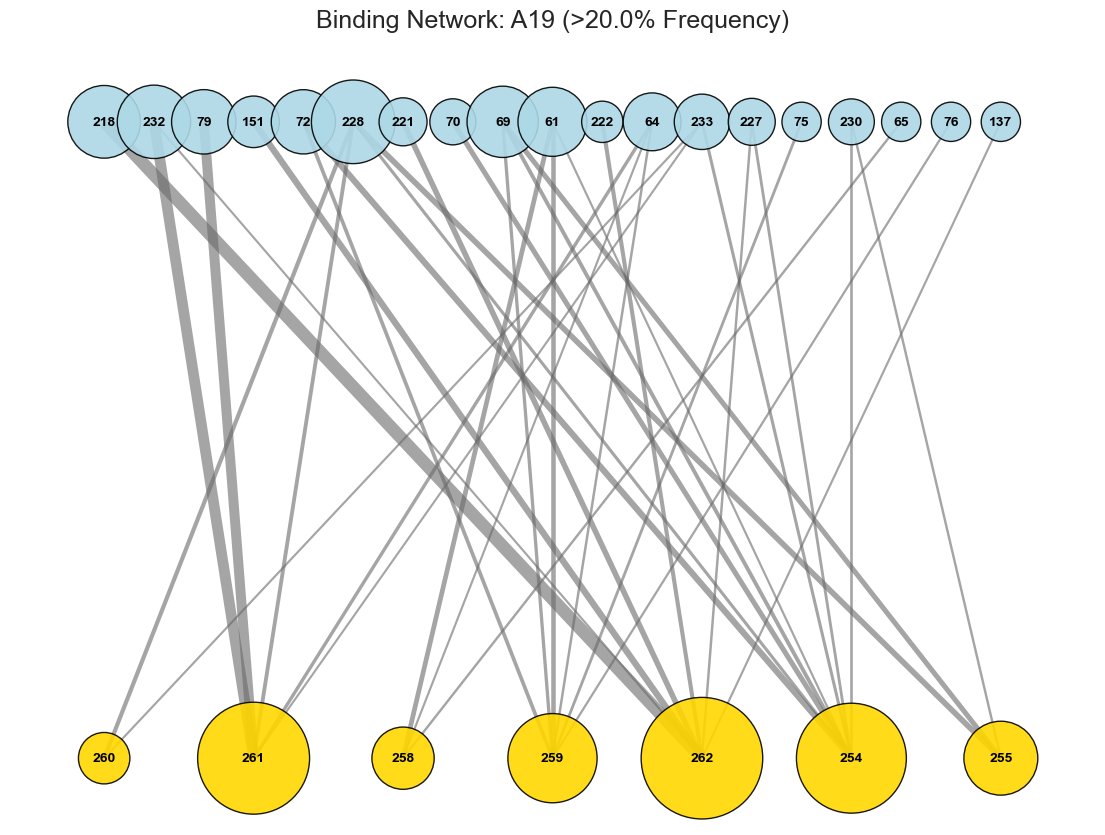

In [36]:
# Cell 26: Intermolecular Binding Network Visualization

print(f"Generating Protein-Ligand interaction network for {system_prefix}...")

# Set the threshold to filter out weak, transient water-mediated bumps
frequency_threshold = 20.0 

G_bind = nx.Graph()

# 1. Populate the graph with explicit node types
for _, row in df_net_inter.iterrows():
    if row['Total_Avg_Freq_%'] >= frequency_threshold:
        
        # We append prefixes to the internal node names just in case numbering overlaps,
        # keeping the logic bulletproof even though your topological IDs are unique.
        lig_node = f"Lig_{row['Lig_Num']}"
        rec_node = f"Rec_{row['Rec_Num']}"
        
        # bipartite=0/1 tells NetworkX which side of the graph the node belongs to
        G_bind.add_node(lig_node, bipartite=0, type='Ligand', real_res=row['Lig_Num'])
        G_bind.add_node(rec_node, bipartite=1, type='Receptor', real_res=row['Rec_Num'])
        
        G_bind.add_edge(lig_node, rec_node, weight=row['Total_Avg_Freq_%'])

# Remove isolated nodes that fell below the frequency threshold
G_bind.remove_nodes_from(list(nx.isolates(G_bind)))

# 2. Setup the Matplotlib figure
plt.figure(figsize=(14, 10))

# Separate the nodes mathematically for the layout engine
ligand_nodes = {n for n, d in G_bind.nodes(data=True) if d['type'] == 'Ligand'}
receptor_nodes = set(G_bind) - ligand_nodes

# Calculate bipartite coordinates (align='horizontal' puts the two lists side-by-side)
pos = nx.bipartite_layout(G_bind, ligand_nodes, align='horizontal')

# 3. Apply Node and Edge Styling
# Gold for the A18 peptide, Light Blue for the GPCR receptor
node_colors = ['gold' if node in ligand_nodes else 'lightblue' for node in G_bind.nodes()]

# Scale node physical sizes based on their total combined interaction weight
node_sizes = [G_bind.degree(node, weight='weight') * 20 for node in G_bind.nodes()]
node_sizes = [max(size, 800) for size in node_sizes] 

edges = G_bind.edges(data=True)
edge_widths = [dict_data['weight'] / 15.0 for _, _, dict_data in edges]

# Extract the pure integers for the visual labels (stripping the "Lig_" and "Rec_" prefixes)
labels = {node: G_bind.nodes[node]['real_res'] for node in G_bind.nodes()}

# 4. Render the Network
nx.draw_networkx_nodes(G_bind, pos, node_size=node_sizes, node_color=node_colors, edgecolors='black', alpha=0.9)
nx.draw_networkx_edges(G_bind, pos, width=edge_widths, alpha=0.6, edge_color='dimgray')
nx.draw_networkx_labels(G_bind, pos, labels=labels, font_size=10, font_weight='bold')

# --- UPDATED: Dynamic Title ---
plt.title(f"Binding Network: {system_prefix} (>{frequency_threshold}% Frequency)", fontsize=18, pad=20)
plt.axis('off')

# --- UPDATED: Global Variables ---
plt.savefig(fn_inter_net_png, dpi=1200, bbox_inches='tight')
plt.savefig(fn_inter_net_pdf, bbox_inches='tight')
print(f"Saved network graph to {fn_inter_net_png} and .pdf")

plt.show()

In [37]:
# Cell 27: Export Intermolecular Binding Network to Cytoscape
import networkx as nx

print(f"Preparing Protein-Ligand binding network for Cytoscape export ({system_prefix})...")

G_bind_export = nx.Graph()

# This must match the threshold you set in Cell 26
# The structure of the data on this file is different to the one on the cell from before
# This is because it needs to be changed to match the syntax of the intramolecular networks
# So cytoscape recognizes the residue nodes.

frequency_threshold = 20.0 

# 1. Rebuild the graph using PURE INTEGER topological IDs
for _, row in df_net_inter.iterrows():
    if row['Total_Avg_Freq_%'] >= frequency_threshold:
        lig_res = int(row['Lig_Num'])
        rec_res = int(row['Rec_Num'])
        
        # 2. Add nodes with metadata for Cytoscape styling
        G_bind_export.add_node(lig_res, Molecule='A18 Ligand', Domain='Peptide')
        G_bind_export.add_node(rec_res, Molecule='AT1R Receptor')
        
        # 3. Add the edge with the interaction frequency weight
        G_bind_export.add_edge(lig_res, rec_res, weight=row['Total_Avg_Freq_%'])

# Clean up any isolated nodes
G_bind_export.remove_nodes_from(list(nx.isolates(G_bind_export)))

# 4. Save to GraphML using Global Variable
nx.write_graphml(G_bind_export, fn_inter_graphml)

print(f"Exported binding network to {fn_inter_graphml} ({G_bind_export.number_of_nodes()} residues, {G_bind_export.number_of_edges()} interactions).")
print("\nMerge Instructions for Cytoscape:")
print("1. Import the TM Wheels graph.")
print("2. Import the Loops graph and Merge.")
print("3. Import this Binding graph and Merge.")
print("4. Your Ligand nodes will automatically wire into the existing GPCR bundle.")

Preparing Protein-Ligand binding network for Cytoscape export (A19)...
Exported binding network to A19_Cytoscape_Binding.graphml (26 residues, 34 interactions).

Merge Instructions for Cytoscape:
1. Import the TM Wheels graph.
2. Import the Loops graph and Merge.
3. Import this Binding graph and Merge.
4. Your Ligand nodes will automatically wire into the existing GPCR bundle.


# Interaction Comparison

### __REMEMBER__

- Check the PATH to the __CONTROL__ and __LIGAND BOUND__ systems
- Check __NAME__ of the __OUTPUT__

In [44]:
# Cell 28: Differential Interaction Analysis (Ligand vs Control)
print(f"Starting differential analysis of intramolecular networks for {system_prefix}...")

# 1. Define paths dynamically
# Make sure this string exactly matches where your baseline Control data is permanently saved
file_control = "AT1R/DATA/CONTROL/CONTROL_Intramolecular_Interactions.csv" # <------------------------------------------------------------------ CONTROL --------------------------------------------------->
file_ligand = fn_intra_csv # Uses the global variable for the current system # <--------------------------------------------------------------LIGAND BOUND ------------------------------------------------->
output_csv = f"{system_prefix}_Differential_Interactions_vs_Ctrl.csv" # <----------------------------------------------------------------------- OUTPUT ---------------------------------------------------->

if system_prefix == "CONTROL":
    print("System is currently set to CONTROL. Differential analysis requires a ligand-bound system. Skipping...")
elif not os.path.exists(file_control) or not os.path.exists(file_ligand):
    print(f"Error: Missing interaction CSVs. Ensure both \n1) {file_control} \n2) {file_ligand} \nexist.")
else:
    # 2. Load both interaction matrices
    df_ctrl = pd.read_csv(file_control, index_col=[0, 1])
    df_ligand = pd.read_csv(file_ligand, index_col=[0, 1])
    
    # 3. Helper function to process, deduplicate, and calculate totals
    def process_and_deduplicate(df, prefix):
        # Sum the average frequencies
        interaction_cols = [col for col in df.columns if '_Avg_%' in col]
        df['Total_Freq'] = df[interaction_cols].sum(axis=1)
        
        # Flatten to expose the original string residues (e.g., "VAL30")
        df_reset = df.reset_index()
        orig_col1 = df_reset.columns[0]
        orig_col2 = df_reset.columns[1]
        
        # Extract integers strictly for mathematical logic
        df_reset['Num_1'] = df_reset[orig_col1].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        df_reset['Num_2'] = df_reset[orig_col2].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
        
        # Directional Deduplication: Use the numbers to sort, but keep the original strings
        def reorder_strings(row):
            if row['Num_1'] <= row['Num_2']:
                return (row[orig_col1], row[orig_col2])
            else:
                return (row[orig_col2], row[orig_col1])
                
        df_reset['Clean_Pair'] = df_reset.apply(reorder_strings, axis=1)
        
        # Drop duplicates keeping the highest frequency
        df_unique = df_reset.sort_values('Total_Freq', ascending=False).drop_duplicates(subset=['Clean_Pair']).copy()
        
        # Structural Filtering (Remove local backbone interactions)
        df_unique['Sequence_Distance'] = abs(df_unique['Num_1'] - df_unique['Num_2'])
        df_tertiary = df_unique[df_unique['Sequence_Distance'] > 4].copy()
        
        # Set the Clean_Pair as the index for a clean structural join
        df_tertiary.set_index('Clean_Pair', inplace=True)
        
        return df_tertiary[['Total_Freq']].rename(columns={'Total_Freq': f'{prefix}_Freq_%'})

    print("Processing baseline Control system...")
    ctrl_clean = process_and_deduplicate(df_ctrl, 'Control')
    
    print(f"Processing {system_prefix} Holo system...")
    ligand_clean = process_and_deduplicate(df_ligand, system_prefix)
    
    # 4. Merge the data on the universal Clean_Pair index
    df_compare = pd.concat([ctrl_clean, ligand_clean], axis=1).fillna(0.0)
    
    # 5. Calculate the Delta (Current System - Control)
    df_compare['Delta_Freq_%'] = df_compare[f'{system_prefix}_Freq_%'] - df_compare['Control_Freq_%']
    
    # Expand the tuple index back into separate string columns for the final display
    df_compare[['Residue_A', 'Residue_B']] = pd.DataFrame(df_compare.index.tolist(), index=df_compare.index)
    
    # Vaporize the tuple index to clean up the DataFrame aesthetics
    df_compare.reset_index(drop=True, inplace=True)
    
    # 6. Filter for significant structural shifts
    significance_threshold = 20.0
    df_significant = df_compare[abs(df_compare['Delta_Freq_%']) >= significance_threshold].copy()
    
    # 7. Sort to find the biggest gains and losses
    df_stabilized = df_significant.sort_values(by='Delta_Freq_%', ascending=False)
    df_destabilized = df_significant.sort_values(by='Delta_Freq_%', ascending=True)
    
    # Clean up column order for final output dynamically based on the prefix
    display_cols = ['Residue_A', 'Residue_B', 'Control_Freq_%', f'{system_prefix}_Freq_%', 'Delta_Freq_%']
    df_stabilized = df_stabilized[display_cols]
    df_destabilized = df_destabilized[display_cols]
    
    # 8. Save the full comparative matrix    
    df_compare_sorted = df_compare.sort_values(by='Delta_Freq_%', ascending=False)
    df_compare_sorted[display_cols].to_csv(output_csv, index=False)
    print(f"Differential matrix safely saved to {output_csv}\n")
    
    # 9. Display the key findings
    print(f"=== TOP STABILIZED INTERACTIONS (Gained/Strengthened due to {system_prefix}) ===")
    display(df_stabilized.head(10))
    
    print(f"\n=== TOP DESTABILIZED INTERACTIONS (Lost/Weakened due to {system_prefix}) ===")
    display(df_destabilized.head(10))

Starting differential analysis of intramolecular networks for A19...
Error: Missing interaction CSVs. Ensure both 
1) AT1R/DATA/CONTROL/CONTROL_Intramolecular_Interactions.csv 
2) A19_Intramolecular_Interactions.csv 
exist.


# SASA Calculations

Surface calculations centered on the residues of the intracellular cavity.

The residues for __AT1R__ are:

- THR 51
- ALA 53
- LAU 57
- LEU 112
- ARG 116
- ILE 231
- ILE 235
- TYR 292
- LYS 295
- GLY 296
- LYS 298

"51 53 57 112 116 231 235 292 295 296 298"

The residues for __AT2R__ are:

1. SER 45
2. ILE 49 
3. MET 104
4. SER 105
5. ASP 107
6. ARG 108
7. GLN 119
8. ARG 121
9. MET 223
10. ALA 224
11. ALA 226
12. VAL 227
13. ASN 280
14. LEU 283
15. TYR 284
16. CYS 285
17. VAL 287
18. LYS 294

"45 49 104 105 107 108 119 121 223 224 226 227 280 283 284 285 287 294"

The residues for __MAS__ are:

- MET 31
- ASN 34
- PHE 36
- ILE 96
- SER 97
- GLU 99
- ARG 100
- SER 103     
- VAL 104
- TYR 110
- MET 173
- LEU 180
- ILE 184
- LEU 196
- VAL 199
- ILE 200
- THR 203
- TYR 250
- PHE 251
- PHE 252
- VAL 253

"31 34 36 96 97 99 100 103 104 110 173 180 184 196 199 200 203 250 251 252 253"

In [58]:
# Cell 29: Intracellular Pocket SASA Calculation
import freesasa
from mdakit_sasa.analysis.sasaanalysis import SASAAnalysis

# Mute the C-library's stderr pipe to prevent Jupyter buffer deadlocks
freesasa.setVerbosity(freesasa.nowarnings)

print(f"Calculating Intracellular Pocket SASA for {system_prefix}...")

# 1. Define the Pocket Selection
pocket_resnums = "31 34 36 96 97 99 100 103 104 110 173 180 184 196 199 200 203 250 251 252 253"
pocket_sel_string = f"protein and resid {pocket_resnums}"

# Ensure MDAnalysis knows what atoms to calculate the surface for
pocket_ag = u_concat.select_atoms(pocket_sel_string)
print(f"Selected {len(pocket_ag)} atoms across {len(pocket_ag.residues)} residues for SASA analysis.")

# 2. Initialize and Run the SASA Calculation
sasa_calc = SASAAnalysis(u_concat, select=pocket_sel_string)

# We can safely turn the progress bar back on now that the C-warnings are dead!
sasa_calc.run(verbose=True)

print("Calculation complete! Proceed to the next cell to export and plot the data.")

Calculating Intracellular Pocket SASA for CONTROL...
Selected 369 atoms across 21 residues for SASA analysis.


  0%|          | 0/1000 [00:00<?, ?it/s]

Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in results 13489 != 21
Residude count do not match the expectation, residue SASA not in 

Calculation complete! Proceed to the next cell to export and plot the data.


Extracting trajectory timing and SASA arrays...
SASA data safely saved to CONTROL_Intracellular_Pocket_SASA.csv
Plot saved to CONTROL_Intracellular_SASA_Plot.png and CONTROL_Intracellular_SASA_Plot.pdf


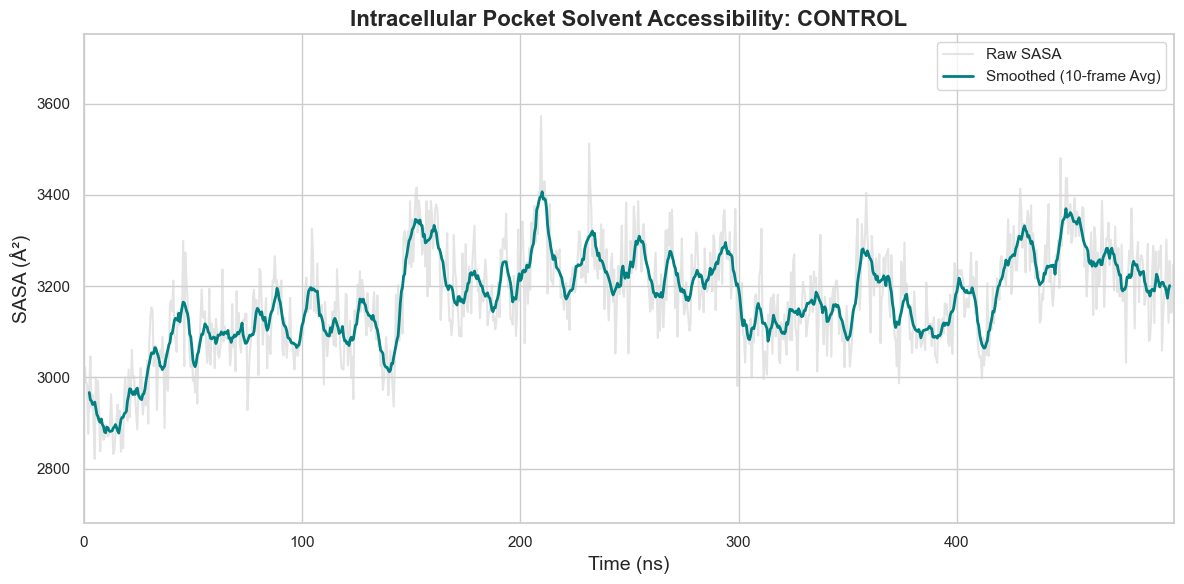

In [59]:
# Cell 30: Export and Plot SASA Data
sns.set_context("notebook")
sns.set_style("whitegrid")

print("Extracting trajectory timing and SASA arrays...")

# --- THE FIX: Robust Continuous Time ---
# 1. Use the verified dt from Cell 2.5 to avoid ChainReader defaulting to 1.0 ps
verified_ns_per_frame = detected_dt_ps / 1000.0  

# 2. Calculate the exact frame stride used during sasa_calc.run() 
# This ensures time scales correctly even if you used step=10
sasa_array_length = len(sasa_calc.results.total_area)
frame_stride = int(total_frames / sasa_array_length) if sasa_array_length > 0 else 1

times_ns = [i * frame_stride * verified_ns_per_frame for i in range(sasa_array_length)]
# ---------------------------------------

# 1. Extract Data into a DataFrame
df_sasa = pd.DataFrame({
    'Frame_Index': range(sasa_array_length),
    'Time_ns': times_ns,
    'Pocket_SASA_Å2': sasa_calc.results.total_area 
})

# 2. Calculate the moving average and handle the NaN edges
df_sasa['SASA_Smoothed'] = df_sasa['Pocket_SASA_Å2'].rolling(window=10, center=True).mean()

# Drop the empty NaN edges so matplotlib doesn't try to draw weird connecting lines
df_plot_smooth = df_sasa.dropna(subset=['SASA_Smoothed'])

# 3. Save the raw data using global filenames
df_sasa.to_csv(fn_sasa_csv, index=False)
print(f"SASA data safely saved to {fn_sasa_csv}")

# 4. Visualize the Data
fig, ax = plt.subplots(figsize=(12, 6))

# Plot raw data in the background (faded)
ax.plot(df_sasa['Time_ns'], df_sasa['Pocket_SASA_Å2'], color='lightgray', alpha=0.6, label='Raw SASA')

# Plot smoothed data in the foreground (Using the cleaned dataframe)
ax.plot(df_plot_smooth['Time_ns'], df_plot_smooth['SASA_Smoothed'], color='teal', linewidth=2.0, label='Smoothed (10-frame Avg)')

ax.set_title(f"Intracellular Pocket Solvent Accessibility: {system_prefix}", fontsize=16, fontweight='bold')
ax.set_xlabel("Time (ns)", fontsize=14)
ax.set_ylabel("SASA (Å²)", fontsize=14)

ax.set_xlim(0, df_sasa['Time_ns'].max())

# Auto-adjust Y-axis to add a little breathing room above and below the data
y_min = df_sasa['Pocket_SASA_Å2'].min() * 0.95
y_max = df_sasa['Pocket_SASA_Å2'].max() * 1.05
ax.set_ylim(y_min, y_max)

ax.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Save Outputs
plt.savefig(fn_sasa_png, dpi=1200, bbox_inches='tight')
plt.savefig(fn_sasa_pdf, bbox_inches='tight')
print(f"Plot saved to {fn_sasa_png} and {fn_sasa_pdf}")

plt.show()

# Intracellular Cavity Volume Exploration

In [60]:
# Cell 31: Run pyKVFinder (Clean In-Memory Stream with Auto-Time)
import numpy as np
import pandas as pd
import MDAnalysis as mda
from MDAnalysis import transformations
from tqdm.auto import tqdm
import pyKVFinder

print(f"Starting true in-memory pyKVFinder calculation for {system_prefix}...")

# 1. Initializing fresh trajectory stream in RAM
print("1. Initializing fresh trajectory stream in RAM...")
u_vol = mda.Universe(topology_path, *trajectory_files)

# 2. On-the-fly Alignment
print("2. Preparing reference and applying on-the-fly alignment...")
protein_sel = "protein"
backbone_sel = "protein and backbone"

u_ref = mda.Universe(topology_path, trajectory_files[0])
u_ref.trajectory[0]
ref_atoms = u_ref.select_atoms(backbone_sel)

align_transform = transformations.fit_rot_trans(u_vol.select_atoms(backbone_sel), ref_atoms)
u_vol.trajectory.add_transformations(align_transform)
print("   -> Alignment transformation locked in.")

# 3. Create the Nx8 Master Array for pyKVFinder 0.9.0
print("3. Building the 8-column Master Array...")
protein = u_vol.select_atoms(protein_sel)

vdw_dict = {'C': 1.70, 'O': 1.52, 'N': 1.55, 'S': 1.80, 'H': 1.20, 'P': 1.80}
radii = np.array([vdw_dict.get(atom.element.upper(), 1.50) for atom in protein])

try:
    chains = protein.chainIDs
except AttributeError:
    try:
        chains = protein.segids
    except AttributeError:
        chains = np.array(['A'] * len(protein))

# Initialize empty object array (N rows, 8 columns)
atomic_data = np.empty((len(protein), 8), dtype=object)

# Fill static columns 
atomic_data[:, 0] = protein.names
atomic_data[:, 1] = protein.resnames
atomic_data[:, 2] = chains
atomic_data[:, 3] = protein.resids
atomic_data[:, 7] = radii

# 4. Define the 0.9.0 Mathematical Bounding Box
print("4. Calculating rigid (4, 3) Bounding Box...")
pocket_resnums = "51 53 57 112 116 231 235 292 295 296 298"
pocket_atoms = u_vol.select_atoms(f"protein and resid {pocket_resnums}")
u_vol.trajectory[0]

box_buffer = 5.0
p_min = pocket_atoms.positions.min(axis=0) - box_buffer
p_max = pocket_atoms.positions.max(axis=0) + box_buffer

# Construct the strictly required 4x3 vertices array
box_vertices = np.array([
    [p_min[0], p_min[1], p_min[2]],  # Point 1: Origin
    [p_max[0], p_min[1], p_min[2]],  # Point 2: X-Limit
    [p_min[0], p_max[1], p_min[2]],  # Point 3: Y-Limit
    [p_min[0], p_min[1], p_max[2]]   # Point 4: Z-Limit
])

# 5. Run the Calculation
print("\n5. Executing pyKVFinder (RAM-to-RAM stream)...")
volumes = []

# Define Grid Resolution and Voxel Volume Math
step_size = 0.6
voxel_volume = step_size ** 3  # A 0.6 Å step means each voxel is 0.216 Å³

for ts in tqdm(u_vol.trajectory, desc="Processing Cavity"):
    
    # Update ONLY the X, Y, Z coordinates for this frame
    atomic_data[:, 4:7] = protein.positions
    
    # Run the exact 0.9.0 API 
    results = pyKVFinder.detect(
        atomic=atomic_data,
        vertices=box_vertices,
        step=step_size,
        probe_in=1.4,
        probe_out=4.0
    )

    # In 0.9.0, detect() returns a tuple: (number_of_cavities, grid_array)
    num_cavities = results[0]
    grid = results[1]

    # Native Volume Calculation
    if num_cavities > 0:
        # Count the voxels for each cavity and multiply by the volume of a single voxel
        cavity_volumes = [np.sum(grid == cav_id) * voxel_volume for cav_id in range(1, num_cavities + 1)]
        
        # Extract the largest cavity found in the bounding box
        volumes.append(max(cavity_volumes))
    else:
        volumes.append(0.0)

# 6. Auto-Timing and Export
print(f"\nCalculation finished! Extracting physical timestamps...")

# THE FIX: Dynamically read the true timestep from the trajectory metadata
auto_ns_per_frame = u_vol.trajectory.dt / 1000.0
print(f"   -> Auto-detected timestep: {auto_ns_per_frame:.3f} ns per frame")

df_vol = pd.DataFrame({
    'Frame': range(len(volumes)),
    'Time_ns': [i * auto_ns_per_frame for i in range(len(volumes))],
    'Volume_Å3': volumes
})

df_vol.to_csv(fn_vol_csv, index=False)
print(f"\nData perfectly scaled and saved to {fn_vol_csv}! Ready for Cell 32.")

Starting true in-memory pyKVFinder calculation for CONTROL...
1. Initializing fresh trajectory stream in RAM...
2. Preparing reference and applying on-the-fly alignment...
   -> Alignment transformation locked in.
3. Building the 8-column Master Array...
4. Calculating rigid (4, 3) Bounding Box...

5. Executing pyKVFinder (RAM-to-RAM stream)...


Processing Cavity:   0%|          | 0/1000 [00:00<?, ?it/s]


Calculation finished! Extracting physical timestamps...
   -> Auto-detected timestep: 0.500 ns per frame

Data perfectly scaled and saved to CONTROL_Intracellular_Pocket_Volume.csv! Ready for Cell 32.


Loading volumetric data from CONTROL_Intracellular_Pocket_Volume.csv...
Plots saved to:
  -> CONTROL_Intracellular_Volume_Plot.png
  -> CONTROL_Intracellular_Volume_Plot.pdf


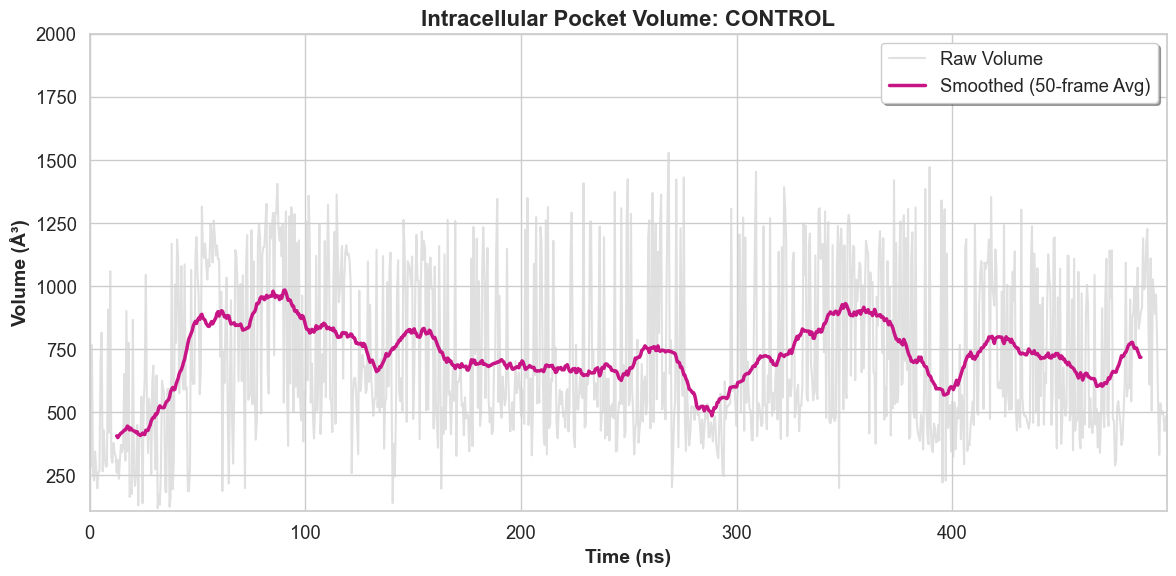

In [61]:
# Cell 32: Plot Intracellular Pocket Volume (pyKVFinder)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- CUSTOMIZATION ---
window_size = 50           # Smoothing window (number of frames)
manual_y_min = None        # Force Y-axis minimum (e.g., 0). Leave as None for Auto.
manual_y_max = 2000        # Force Y-axis maximum (e.g., 3000). Leave as None for Auto.
# ---------------------

print(f"Loading volumetric data from {fn_vol_csv}...")

# 1. Load data directly from disk (Safe from kernel restarts)
try:
    df_vol = pd.read_csv(fn_vol_csv)
except FileNotFoundError:
    print(f"Error: Could not find {fn_vol_csv}. Please run Cell 31 first.")
    raise

# 2. Calculate Moving Average 
df_vol['Volume_Smoothed'] = df_vol['Volume_Å3'].rolling(window=window_size, center=True).mean()

# 3. Visualization Setup
sns.set_context("notebook", font_scale=1.2)
sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

# Plot raw data in the background (faded)
ax.plot(df_vol['Time_ns'], df_vol['Volume_Å3'], 
        color='lightgray', alpha=0.7, label='Raw Volume')

# Plot smoothed data in the foreground (solid line)
df_plot = df_vol.dropna(subset=['Volume_Smoothed'])
ax.plot(df_plot['Time_ns'], df_plot['Volume_Smoothed'], 
        color='mediumvioletred', linewidth=2.5, label=f'Smoothed ({window_size}-frame Avg)')

# Formatting
ax.set_title(f"Intracellular Pocket Volume: {system_prefix}", fontsize=16, fontweight='bold')
ax.set_xlabel("Time (ns)", fontsize=14, fontweight='bold')
ax.set_ylabel("Volume (Å³)", fontsize=14, fontweight='bold')

ax.set_xlim(0, df_vol['Time_ns'].max())

# --- THE FIX: Smart Y-Axis Scaling ---
# Calculate the automatic limits first
auto_y_min = max(0, df_vol['Volume_Å3'].min() * 0.9)
auto_y_max = df_vol['Volume_Å3'].max() * 1.1

# Apply your manual limits if you typed a number, otherwise use the auto limits
final_y_min = manual_y_min if manual_y_min is not None else auto_y_min
final_y_max = manual_y_max if manual_y_max is not None else auto_y_max

ax.set_ylim(final_y_min, final_y_max)
# -------------------------------------

ax.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()

# Save Outputs
plt.savefig(fn_vol_png, dpi=1200, bbox_inches='tight')
plt.savefig(fn_vol_pdf, bbox_inches='tight')
print(f"Plots saved to:\n  -> {fn_vol_png}\n  -> {fn_vol_pdf}")

plt.show()

## Plip Experiment ##

In [7]:
# # Cell 19: Extract Trajectory Frames to PDB Files
# import MDAnalysis as mda
# import os
# import gc

# # Define which trajectory to extract (0 extracts the first one in your list)
# target_trajectory = trajectory_files[0]
# print(f"Starting PDB extraction for: {target_trajectory}")

# # Create a dedicated directory for the PDB files
# pdb_out_dir = "AT1R_Rep1_PDB_Frames"
# os.makedirs(pdb_out_dir, exist_ok=True)

# # 1. Load the Universe
# u = mda.Universe(topology_path, target_trajectory)

# # Select the protein (PLIP usually requires full atomic detail, so we keep everything)
# protein_ag = u.select_atoms("protein")

# total_frames = len(u.trajectory)
# print(f"Writing {total_frames} frames to {pdb_out_dir}/ ...")

# # 2. Iterate through the trajectory and write each frame
# for ts in u.trajectory:
#     frame_idx = ts.frame
    
#     # Construct the filename (e.g., frame_0000.pdb)
#     pdb_filename = os.path.join(pdb_out_dir, f"frame_{frame_idx:04d}.pdb")
    
#     # Write the current coordinates of the selection to a PDB file
#     protein_ag.write(pdb_filename)
    
#     # Optional progress tracker so you know it has not frozen
#     if frame_idx % 500 == 0 and frame_idx > 0:
#         print(f" - Processed {frame_idx} / {total_frames} frames")

# # Free memory
# del u
# gc.collect()

# print("\nPDB extraction complete.")

Starting PDB extraction for: AT1R/CONTROL/AT1R_prod2_r1.nc
Writing 1000 frames to AT1R_Rep1_PDB_Frames/ ...
 - Processed 500 / 1000 frames

PDB extraction complete.


In [1]:
# Cell 27: Dependencies for PLIP Parsing and Comparison
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd

In [2]:
# Cell 28: Path Definitions
plip_results_dir = "AT1R_Rep1_PLIP_Results"
plip_output_csv = "AT1R_PLIP_Aggregated_Interactions.csv"

prolif_input_csv = "AT1R_ProLIF_Aggregated_Interactions.csv"
comparison_output_csv = "AT1R_ProLIF_vs_PLIP_Comparison.csv"

In [8]:
# Cell 29: Parse PLIP XML Outputs into a Frequency Matrix (Corrected)
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd

print(f"Starting to parse PLIP XML files from {plip_results_dir}...")

xml_files = sorted(glob.glob(os.path.join(plip_results_dir, "*.xml")))
total_frames = len(xml_files)

if total_frames == 0:
    raise FileNotFoundError(f"No XML files found in {plip_results_dir}. Please check the path.")

interaction_tags = {
    'hydrogen_bonds': 'hydrogen_bond',
    'hydrophobic_interactions': 'hydrophobic_interaction',
    'salt_bridges': 'salt_bridge',
    'pi_stacks': 'pi_stack',
    'pi_cation_interactions': 'pi_cation_interaction',
    'water_bridges': 'water_bridge',
    'halogen_bonds': 'halogen_bond'
}

plip_records = []

for file_path in xml_files:
    basename = os.path.basename(file_path)
    try:
        # Extract the frame number to track exactly when interactions occur
        frame_num = int(''.join(filter(str.isdigit, basename)))
    except ValueError:
        frame_num = -1 
        
    try:
        tree = ET.parse(file_path)
        root = tree.getroot()
        
        interactions_node = root.find('.//bindingsite/interactions')
        
        if interactions_node is not None:
            for category, item_tag in interaction_tags.items():
                category_node = interactions_node.find(category)
                
                if category_node is not None:
                    for item in category_node.findall(item_tag):
                        res1_elem = item.find('resnr')
                        res2_elem = item.find('resnr_lig')
                        
                        if res1_elem is not None and res2_elem is not None:
                            res_pair = sorted([int(res1_elem.text), int(res2_elem.text)])
                            
                            plip_records.append({
                                'Frame': frame_num,
                                'Residue_1': res_pair[0],
                                'Residue_2': res_pair[1],
                                'Interaction_Type': category
                            })
    except ET.ParseError:
        print(f"Warning: Could not parse XML in {basename}.")

df_plip_raw = pd.DataFrame(plip_records)
print(f"Parsing complete. Extracted {len(df_plip_raw)} total atom-to-atom interaction events.")

# THE FIX: Drop redundant atom-to-atom contacts within the exact same frame
# This reduces the data so that a specific interaction type between two residues 
# can only be counted a maximum of 1 time per frame.
df_plip_unique = df_plip_raw.drop_duplicates(subset=['Frame', 'Residue_1', 'Residue_2', 'Interaction_Type'])

print(f"Collapsed into {len(df_plip_unique)} unique residue-to-residue frame events.")

# 1. Group and count (which now accurately reflects the number of frames)
df_plip_counts = df_plip_unique.groupby(['Residue_1', 'Residue_2', 'Interaction_Type']).size().unstack(fill_value=0)

# 2. Calculate percentage
df_plip_freq = (df_plip_counts / total_frames) * 100

df_plip_freq = df_plip_freq.add_suffix('_PLIP_%')

df_plip_freq.to_csv(plip_output_csv)
print(f"Corrected standalone PLIP matrix safely saved to {plip_output_csv}")

Starting to parse PLIP XML files from AT1R_Rep1_PLIP_Results...
Parsing complete. Extracted 759990 total atom-to-atom interaction events.
Collapsed into 424721 unique residue-to-residue frame events.
Corrected standalone PLIP matrix safely saved to AT1R_PLIP_Aggregated_Interactions.csv


In [10]:
# Cell 30: Merge ProLIF and PLIP Matrices
import pandas as pd

print("Loading ProLIF data and standardizing residue nomenclature...")
df_prolif = pd.read_csv("AT1R_ProLIF_Aggregated_Interactions.csv", index_col=[0, 1])
df_prolif = df_prolif.rename_axis(index={'ligand': 'Residue_1', 'protein': 'Residue_2'})
df_prolif_reset = df_prolif.reset_index()

# Extract just the digits (e.g., "VAL98.0" -> 98) using a regular expression
df_prolif_reset['Residue_1'] = df_prolif_reset['Residue_1'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
df_prolif_reset['Residue_2'] = df_prolif_reset['Residue_2'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
df_prolif_clean = df_prolif_reset.set_index(['Residue_1', 'Residue_2'])

print("Loading corrected PLIP matrix and merging datasets...")
df_plip_freq = pd.read_csv("AT1R_PLIP_Aggregated_Interactions.csv", index_col=[0, 1])

# The 'outer' join ensures interactions unique to either tool are preserved and filled with 0.0
df_comparison = df_prolif_clean.join(df_plip_freq, how='outer').fillna(0.0)

output_csv = "AT1R_ProLIF_vs_PLIP_Comparison.csv"
df_comparison.to_csv(output_csv)
print(f"Comparison matrix saved to {output_csv}")

Loading ProLIF data and standardizing residue nomenclature...
Loading corrected PLIP matrix and merging datasets...
Comparison matrix saved to AT1R_ProLIF_vs_PLIP_Comparison.csv


In [11]:
# Cell 31: Taxonomy Mapping and Deduplication
import pandas as pd

print("Mapping ProLIF granular interactions to PLIP broad categories...")
df_comp = pd.read_csv("AT1R_ProLIF_vs_PLIP_Comparison.csv")

# Map specific ProLIF columns to overarching PLIP-equivalent categories
taxonomy_map = {
    'ProLIF_Mapped_Hydrogen_Bonds_%': ['HBAcceptor_Avg_%', 'HBDonor_Avg_%'],
    'ProLIF_Mapped_Pi_Stacks_%': ['PiStacking_Avg_%', 'FaceToFace_Avg_%', 'EdgeToFace_Avg_%'],
    'ProLIF_Mapped_Salt_Bridges_%': ['Anionic_Avg_%', 'Cationic_Avg_%'],
    'ProLIF_Mapped_Pi_Cation_%': ['CationPi_Avg_%'], 
    'ProLIF_Mapped_Hydrophobic_%': ['VdWContact_Avg_%']
}

for broad_cat, sub_cats in taxonomy_map.items():
    existing_cols = [col for col in sub_cats if col in df_comp.columns]
    if existing_cols:
        # max() prevents the sum of sub-categories from exceeding 100% per residue pair
        df_comp[broad_cat] = df_comp[existing_cols].max(axis=1)
    else:
        df_comp[broad_cat] = 0.0

prolif_mapped_cols = list(taxonomy_map.keys())
plip_cols = [col for col in df_comp.columns if '_PLIP_%' in col]

df_comp['Total_Mapped_ProLIF_%'] = df_comp[prolif_mapped_cols].sum(axis=1)
df_comp['Total_Broad_PLIP_%'] = df_comp[plip_cols].sum(axis=1)

print("Resolving directional duplicates (e.g., 54-51 and 51-54)...")
# lambda creates a sorted tuple from the two residues
df_comp['Sorted_Pair'] = df_comp.apply(lambda row: tuple(sorted([int(row['Residue_1']), int(row['Residue_2'])])), axis=1)

df_clean = df_comp.groupby('Sorted_Pair').agg({
    'Total_Mapped_ProLIF_%': 'max',
    'Total_Broad_PLIP_%': 'max'
}).reset_index()

# Unpack the tuple back into independent columns for the final CSV
df_clean[['Residue_1', 'Residue_2']] = pd.DataFrame(df_clean['Sorted_Pair'].tolist(), index=df_clean.index)
df_clean = df_clean[['Residue_1', 'Residue_2', 'Total_Mapped_ProLIF_%', 'Total_Broad_PLIP_%']]
df_clean = df_clean.sort_values(by='Total_Mapped_ProLIF_%', ascending=False)

output_csv = "AT1R_Taxonomy_Mapped_Unique_Pairs.csv"
df_clean.to_csv(output_csv, index=False)
print(f"Clean list of unique, taxonomy-mapped interactions saved to {output_csv}")
display(df_clean.head())

Mapping ProLIF granular interactions to PLIP broad categories...
Resolving directional duplicates (e.g., 54-51 and 51-54)...
Clean list of unique, taxonomy-mapped interactions saved to AT1R_Taxonomy_Mapped_Unique_Pairs.csv


,Residue_1,Residue_2,Total_Mapped_ProLIF_%,Total_Broad_PLIP_%
20,3,163,277.244742,108.8
836,115,130,249.576114,80.2
595,81,83,246.675401,59.0
1605,263,265,245.911408,186.6
1416,226,230,231.356417,153.0


Loading clean list for visualization...
Saved plots as AT1R_Adjusted_Tool_Comparison.png (1200 DPI) and AT1R_Adjusted_Tool_Comparison.pdf


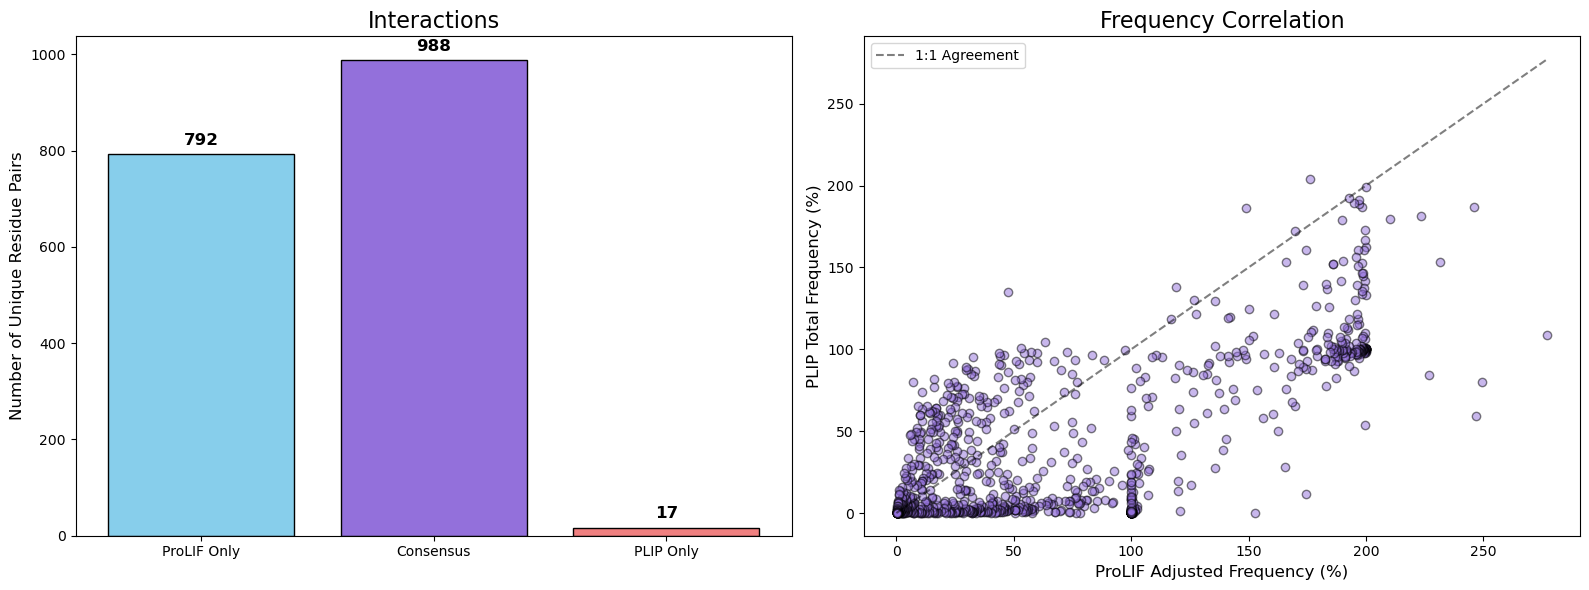

In [14]:
# Cell 32: Standardized Consensus Visualization
import pandas as pd
import matplotlib.pyplot as plt

print("Loading clean list for visualization...")
df_clean = pd.read_csv("AT1R_Taxonomy_Mapped_Unique_Pairs.csv")

# Apply boolean True/False logic to interaction frequencies
df_clean['ProLIF_Detected'] = df_clean['Total_Mapped_ProLIF_%'] > 0.0
df_clean['PLIP_Detected'] = df_clean['Total_Broad_PLIP_%'] > 0.0

# Count populations using the tilde (~) for NOT logic
prolif_only = len(df_clean[df_clean['ProLIF_Detected'] & ~df_clean['PLIP_Detected']])
plip_only = len(df_clean[~df_clean['ProLIF_Detected'] & df_clean['PLIP_Detected']])
consensus = len(df_clean[df_clean['ProLIF_Detected'] & df_clean['PLIP_Detected']])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

labels = ['ProLIF Only', 'Consensus', 'PLIP Only']
counts = [prolif_only, consensus, plip_only]
colors = ['skyblue', 'mediumpurple', 'lightcoral']

ax1.bar(labels, counts, color=colors, edgecolor='black')
ax1.set_title('Interactions', fontsize=16)
ax1.set_ylabel('Number of Unique Residue Pairs', fontsize=12)

for i, v in enumerate(counts):
    ax1.text(i, v + (max(counts) * 0.02), str(v), ha='center', fontweight='bold', fontsize=12)

df_consensus = df_clean[df_clean['ProLIF_Detected'] & df_clean['PLIP_Detected']]

ax2.scatter(df_consensus['Total_Mapped_ProLIF_%'], df_consensus['Total_Broad_PLIP_%'], 
            alpha=0.5, color='mediumpurple', edgecolor='black')

max_val = max(df_consensus['Total_Mapped_ProLIF_%'].max(), df_consensus['Total_Broad_PLIP_%'].max())
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='1:1 Agreement')

ax2.set_title('Frequency Correlation', fontsize=16)
ax2.set_xlabel('ProLIF Adjusted Frequency (%)', fontsize=12)
ax2.set_ylabel('PLIP Total Frequency (%)', fontsize=12)
ax2.legend()

plt.tight_layout()

plt.savefig("AT1R_Adjusted_Tool_Comparison.png", dpi=1200, bbox_inches='tight')
plt.savefig("AT1R_Adjusted_Tool_Comparison.pdf", bbox_inches='tight')
print("Saved plots as AT1R_Adjusted_Tool_Comparison.png (1200 DPI) and AT1R_Adjusted_Tool_Comparison.pdf")

plt.show()

# Diedrales

In [6]:
# Cell: GPCR Micro-Switch Dihedral Configuration and Extraction
import pandas as pd
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import dihedrals

print(f"Configuring Target Micro-Switches for {system}...\n")

# --- 1. Dynamic Motif Definitions ---
motifs_at1r = {'Ionic_Lock_R': 116, 'Toggle_Switch_W': 243, 'NPxxY_Y': 292}
motifs_at2r = {'Ionic_Lock_R': 108, 'Toggle_Switch_W': 235, 'NPxxY_Y': 284}
motifs_mas1 = {'Ionic_Lock_R': 100, 'Toggle_Switch_W': None, 'NPxxY_Y': 250}

if "AT2R" in system.upper():
    target_motifs = motifs_at2r
    print(" -> AT2R detected. Loading AT2R motif targets.")
elif "MAS" in system.upper():
    target_motifs = motifs_mas1
    print(" -> MAS1 detected. Loading MAS1 motif targets. (TM6 Toggle is naturally absent).")
elif "AT1R" in system.upper():
    target_motifs = motifs_at1r
    print(" -> AT1R detected. Loading AT1R motif targets.")
else:
    print(f" -> WARNING: '{system}' not explicitly recognized. Defaulting to AT1R.")
    target_motifs = motifs_at1r

# --- 2. Output Registry ---
fn_dihedral_csv = f"{system_prefix}_Dihedral_Chi1.csv"
fn_dihedral_png = f"{system_prefix}_Dihedral_Distributions.png"
fn_dihedral_pdf = f"{system_prefix}_Dihedral_Distributions.pdf"

# --- 3. Dihedral Extraction from u_concat ---
print("\nExtracting Chi-1 Dihedral Angles from trajectory...")

chi1_atom_names = ['N', 'CA', 'CB', 'CG']

# Initialize the DataFrame with Frames and the exact Chemical Time
sys_df = pd.DataFrame({'Frame': np.arange(len(u_concat.trajectory))})

# THE FIX: Calculate Time_ns dynamically using the metadata from Cell 2.5
sys_df['Time_ns'] = sys_df['Frame'] * (detected_dt_ps / 1000.0)

for motif_name, res_id in target_motifs.items():
    if res_id is None:
        continue # Skips MAS1 toggle
        
    # Select the 4 atoms defining the Chi-1 dihedral
    atom_groups = [u_concat.select_atoms(f"resid {res_id} and name {atom}") for atom in chi1_atom_names]
    
    if any(len(ag) == 0 for ag in atom_groups):
        print(f"   -> Warning: Missing atoms for {motif_name} (Residue {res_id}). Skipping.")
        continue
        
    target_dihedral_atoms = atom_groups[0] + atom_groups[1] + atom_groups[2] + atom_groups[3]
    dih_analysis = dihedrals.Dihedral([target_dihedral_atoms]).run()
    
    # Store angles
    sys_df[motif_name] = dih_analysis.results.angles[:, 0]
    print(f"   -> {motif_name} (Residue {res_id}): Extracted {len(sys_df)} frames.")

# Reorder columns to ensure Frame and Time_ns are the first two columns
cols = ['Frame', 'Time_ns'] + [col for col in sys_df.columns if col not in ['Frame', 'Time_ns']]
sys_df = sys_df[cols]

# Save Data
sys_df.to_csv(fn_dihedral_csv, index=False)
print(f"\nSuccess! Dihedral data saved to: {fn_dihedral_csv}")

Configuring Target Micro-Switches for MAS2...

 -> MAS1 detected. Loading MAS1 motif targets. (TM6 Toggle is naturally absent).

Extracting Chi-1 Dihedral Angles from trajectory...
   -> Ionic_Lock_R (Residue 100): Extracted 3000 frames.
   -> NPxxY_Y (Residue 250): Extracted 3000 frames.

Success! Dihedral data saved to: A18_Dihedral_Chi1.csv


Generating Dihedral Distribution plots for MAS2...

 -> Saved Plot: A18_Dihedral_Distributions.png | .pdf


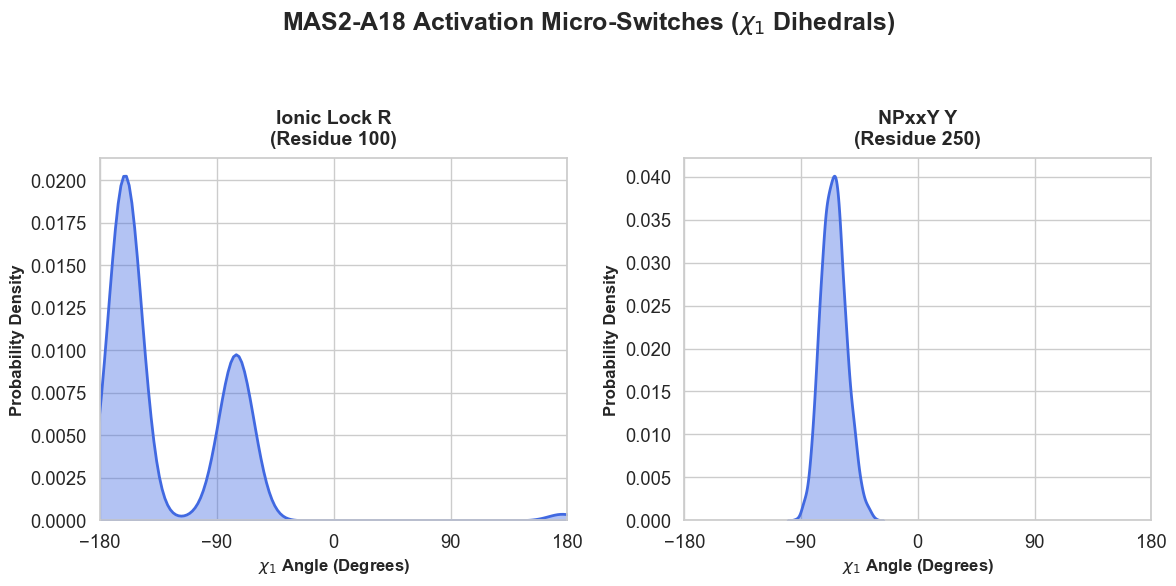

In [7]:
# Cell: Visualizing Dihedral Conformational States
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

print(f"Generating Dihedral Distribution plots for {system}...\n")

active_motifs = [m for m, r in target_motifs.items() if r is not None]
n_plots = len(active_motifs)

fig_dih, axes_dih = plt.subplots(nrows=1, ncols=n_plots, figsize=(6 * n_plots, 6))
fig_dih.suptitle(f'{system}-{system_prefix} Activation Micro-Switches ($\chi_1$ Dihedrals)', fontsize=18, fontweight='bold', y=0.98)

# Ensure axes_dih is iterable
if n_plots == 1:
    axes_dih = [axes_dih]

for idx, motif_name in enumerate(active_motifs):
    ax = axes_dih[idx]
    sys_data = sys_df[motif_name].dropna()
    
    if not sys_data.empty:
        sns.kdeplot(
            data=sys_data, 
            ax=ax, 
            color='royalblue', # Standard color for a single system view
            fill=True, 
            alpha=0.4,
            linewidth=2
        )
    
    # Formatting
    ax.set_title(f"{motif_name.replace('_', ' ')}\n(Residue {target_motifs[motif_name]})", fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel("$\chi_1$ Angle (Degrees)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Probability Density", fontsize=12, fontweight='bold')
    
    ax.set_xlim(-180, 180)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(90))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(45))
    ax.tick_params(axis='both', which='major', length=6)

plt.tight_layout(rect=[0, 0, 1, 0.93])

# Explicit Export & Display
fig_dih.savefig(fn_dihedral_png, dpi=300, bbox_inches='tight')
fig_dih.savefig(fn_dihedral_pdf, bbox_inches='tight')
print(f" -> Saved Plot: {fn_dihedral_png} | .pdf")
plt.show()

Generating Linear Dihedral Analysis plots for MAS2...

 -> Saved Linear Analysis Plot: A18_Dihedral_Linear_Analysis.png | .pdf


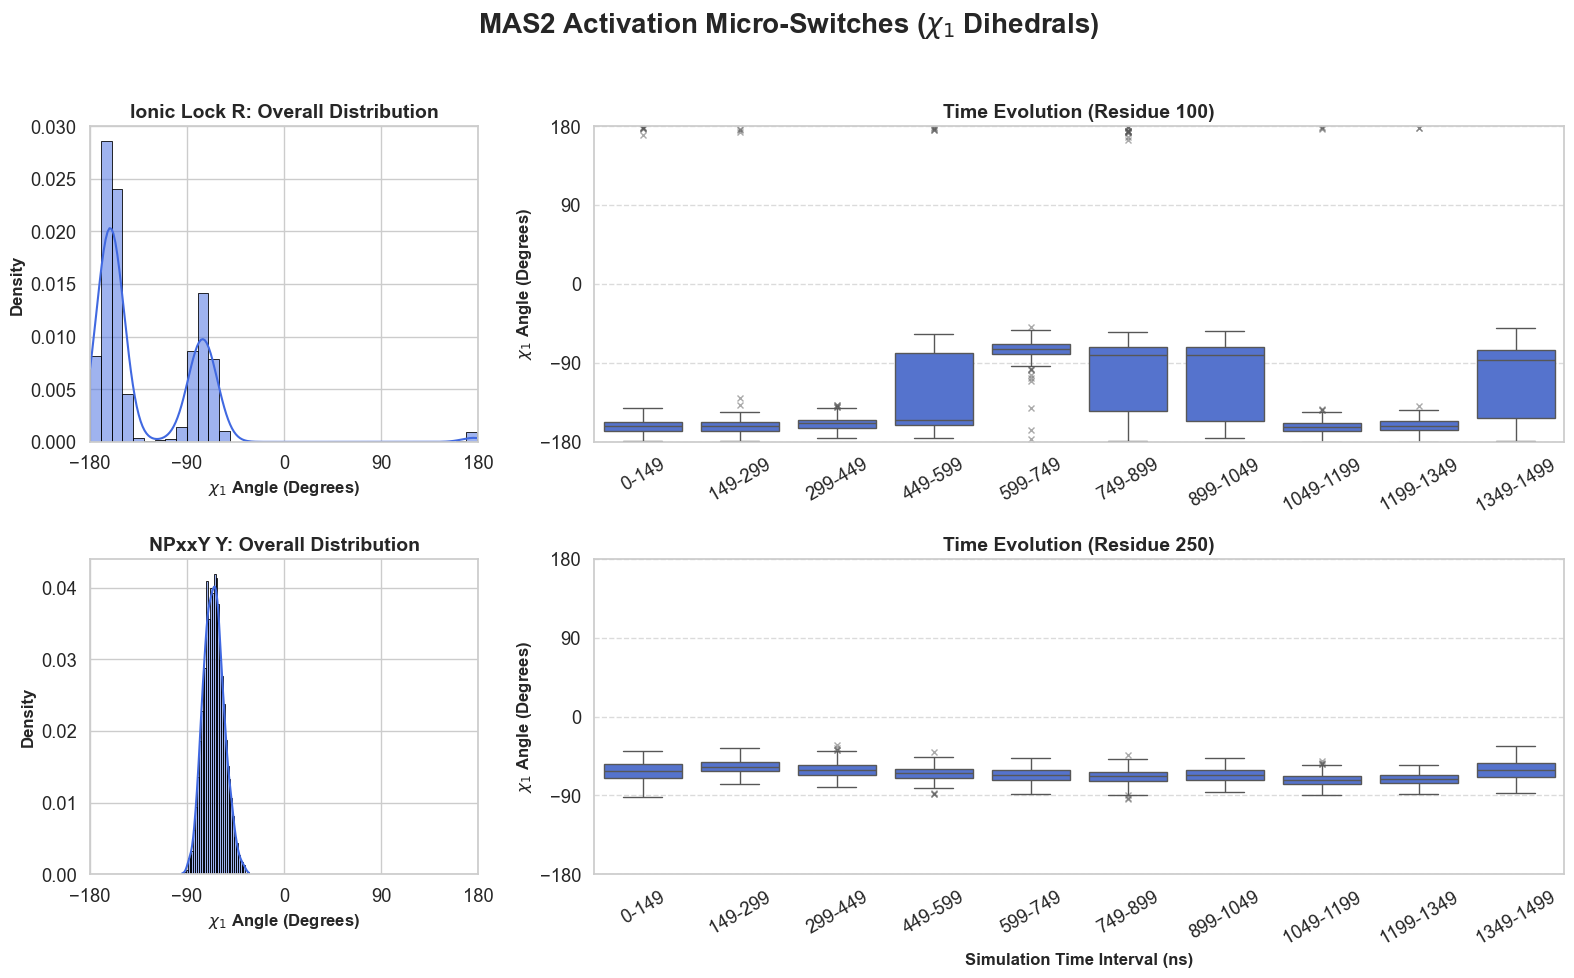

In [8]:
# Cell 21: Visualizing Dihedral Conformational States (Histograms & Time-Binned Boxplots)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd

# --- 1. NUKE THE CACHE ---
plt.close('all')

print(f"Generating Linear Dihedral Analysis plots for {system}...\n")

# ==============================================================================
# --- 2. USER CONFIGURATION ---
# ==============================================================================
time_step_ns = 0.5           # Length of each frame in nanoseconds (Adjust based on your stride)
target_time_intervals = 10   # Exactly how many time bins (boxes) you want on the X-axis
histogram_bins = 36          # Number of bins for the histogram (e.g., 36 bins = 10-degree increments)

# ==============================================================================
# --- 3. DYNAMIC TIME BINNING ---
# ==============================================================================
sys_df['Time_ns'] = sys_df['Frame'] * time_step_ns
max_time = sys_df['Time_ns'].max()

# np.linspace mathematically guarantees exactly 'target_time_intervals' equal slices
bins = np.linspace(0, max_time, target_time_intervals + 1)
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]

sys_df['Time_Bin'] = pd.cut(sys_df['Time_ns'], bins=bins, labels=labels, include_lowest=True)

# ==============================================================================
# --- 4. FIGURE SETUP ---
# ==============================================================================
fn_dihedral_linear_png = f"{system_prefix}_Dihedral_Linear_Analysis.png"
fn_dihedral_linear_pdf = f"{system_prefix}_Dihedral_Linear_Analysis.pdf"

active_motifs = [m for m, r in target_motifs.items() if r is not None]
n_motifs = len(active_motifs)

# Create a grid: 1 Row per Motif, 2 Columns (Histogram Left, Boxplot Right)
fig_dih, axes_dih = plt.subplots(
    nrows=n_motifs, 
    ncols=2, 
    figsize=(16, 5 * n_motifs), 
    gridspec_kw={'width_ratios': [1, 2.5]} # Makes the boxplot wider than the histogram
)
fig_dih.suptitle(f'{system} Activation Micro-Switches ($\chi_1$ Dihedrals)', fontsize=20, fontweight='bold', y=0.98)

# Flatten axes for easy indexing if there is only 1 motif
if n_motifs == 1:
    axes_dih = [axes_dih]

# ==============================================================================
# --- 5. PLOTTING LOOP ---
# ==============================================================================
for idx, motif_name in enumerate(active_motifs):
    ax_hist = axes_dih[idx][0]
    ax_box = axes_dih[idx][1]
    
    # -----------------------------------------
    # PLOT A: Overall Histogram
    # -----------------------------------------
    sns.histplot(
        data=sys_df, 
        x=motif_name, 
        bins=histogram_bins, 
        ax=ax_hist, 
        color='royalblue', 
        edgecolor='black',
        stat='density', # Shows probability density rather than raw frame counts
        kde=True        # Overlays the smooth curve
    )
    
    ax_hist.set_title(f"{motif_name.replace('_', ' ')}: Overall Distribution", fontsize=14, fontweight='bold')
    ax_hist.set_xlabel("$\chi_1$ Angle (Degrees)", fontsize=12, fontweight='bold')
    ax_hist.set_ylabel("Density", fontsize=12, fontweight='bold')
    
    ax_hist.set_xlim(-180, 180)
    ax_hist.xaxis.set_major_locator(ticker.MultipleLocator(90))
    ax_hist.xaxis.set_minor_locator(ticker.MultipleLocator(45))
    
    # -----------------------------------------
    # PLOT B: Time-Binned Boxplot
    # -----------------------------------------
    sns.boxplot(
        data=sys_df, 
        x='Time_Bin', 
        y=motif_name, 
        ax=ax_box, 
        color='royalblue',
        flierprops={"marker": "x", "markersize": 4, "alpha": 0.5} # Styles the outlier points
    )
    
    ax_box.set_title(f"Time Evolution (Residue {target_motifs[motif_name]})", fontsize=14, fontweight='bold')
    ax_box.set_ylabel("$\chi_1$ Angle (Degrees)", fontsize=12, fontweight='bold')
    
    # Only label the X-axis fully on the bottom row to keep it clean
    is_last_plot = (idx == n_motifs - 1)
    ax_box.set_xlabel("Simulation Time Interval (ns)" if is_last_plot else "", fontsize=12, fontweight='bold')
    ax_box.tick_params(axis='x', rotation=30)
    
    ax_box.set_ylim(-180, 180)
    ax_box.yaxis.set_major_locator(ticker.MultipleLocator(90))
    ax_box.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# ==============================================================================
# --- 6. EXPORT ---
# ==============================================================================
fig_dih.savefig(fn_dihedral_linear_png, dpi=300, bbox_inches='tight')
fig_dih.savefig(fn_dihedral_linear_pdf, bbox_inches='tight')

print(f" -> Saved Linear Analysis Plot: {fn_dihedral_linear_png} | .pdf")
plt.show()

In [10]:
# Cell 22: Interactive Py3Dmol Visualization of Activation Motifs
import py3Dmol
import MDAnalysis as mda
import os
import ipywidgets as widgets
from IPython.display import display, clear_output

print(f"Initializing Interactive Motif Viewer for {system}...\n")

# --- 1. Define Motif Dictionary based on System ---
motifs_at1r = {'Ionic_Lock_R': 116, 'Toggle_Switch_W': 243, 'NPxxY_Y': 292}
motifs_at2r = {'Ionic_Lock_R': 108, 'Toggle_Switch_W': 235, 'NPxxY_Y': 284}
motifs_mas1 = {'Ionic_Lock_R': 100, 'Toggle_Switch_W': None, 'NPxxY_Y': 250}

if "AT2R" in system.upper():
    active_motifs = motifs_at2r
elif "MAS" in system.upper():
    active_motifs = motifs_mas1
else:
    active_motifs = motifs_at1r

# --- 2. Setup Frame Targets ---
start_frame = 0
end_frame = total_frames - 1

# Create an output area so the widget doesn't duplicate the 3D viewer when clicked
out = widgets.Output()

# --- 3. Rendering Function ---
def render_motif(target_motif):
    with out:
        clear_output(wait=True)
        
        target_res = active_motifs[target_motif]
        
        if target_res is None:
            print(f"\n[!] The {target_motif.replace('_', ' ')} is naturally absent in {system}.")
            return

        print(f"Rendering: {target_motif.replace('_', ' ')} (Residue {target_res})")
        print(f"Comparing Frame {start_frame} ({0.0} ns) vs. Frame {end_frame} ({total_time_ns:.2f} ns)\n")
        
        view = py3Dmol.view(width=800, height=400, linked=True, viewergrid=(1,2))
        
        def render_frame_in_viewer(frame_idx, viewer_col):
            u_concat.trajectory[frame_idx]
            
            full_protein = u_concat.select_atoms("protein")
            u_concat.atoms.translate(-full_protein.center_of_mass())
            
            target_selection = u_concat.select_atoms(f"resid {target_res}")
            resname = target_selection.resnames[0]
            com = target_selection.center_of_mass()
            
            temp_pdb = f"temp_frame_{frame_idx}.pdb"
            full_protein.write(temp_pdb)
            
            with open(temp_pdb, 'r') as f:
                pdb_data = f.read()
                
            view.addModel(pdb_data, 'pdb', viewer=(0, viewer_col))
            view.setStyle({'model': -1}, {'cartoon': {'color': 'lightgray', 'opacity': 0.4}}, viewer=(0, viewer_col))
            
            # Use distinct colors depending on the motif being viewed
            if "Ionic" in target_motif:
                color_scheme = "greenCarbon"
            elif "Toggle" in target_motif:
                color_scheme = "magentaCarbon"
            else:
                color_scheme = "orangeCarbon"
                
            view.setStyle({'model': -1, 'resi': str(target_res)}, {'stick': {'colorscheme': color_scheme, 'radius': 0.2}}, viewer=(0, viewer_col))
            
            time_ns = (frame_idx * detected_dt_ps) / 1000.0
            label_text = f"{resname}{target_res}\n({time_ns:.1f} ns)"
            view.addLabel(label_text, 
                          {'position': {'x': com[0], 'y': com[1], 'z': com[2]}, 
                           'backgroundColor': 'black', 'fontColor': 'white', 'backgroundOpacity': 0.7, 'fontSize': 14}, 
                          viewer=(0, viewer_col))
            
            view.zoomTo({'resi': str(target_res)}, viewer=(0, viewer_col))
            
            if os.path.exists(temp_pdb):
                os.remove(temp_pdb)

        # Render Left (Start) and Right (End)
        render_frame_in_viewer(start_frame, viewer_col=0)
        render_frame_in_viewer(end_frame, viewer_col=1)
        
        view.show()

# --- 4. Interactive Widget Setup ---
dropdown = widgets.Dropdown(
    options=list(active_motifs.keys()),
    description='Select Motif:',
    disabled=False,
    style={'description_width': 'initial'}
)

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        render_motif(change['new'])

dropdown.observe(on_change)

# Display the menu and render the first option automatically
display(dropdown)
display(out)
render_motif(dropdown.value)

Initializing Interactive Motif Viewer for MAS2...



Dropdown(description='Select Motif:', options=('Ionic_Lock_R', 'Toggle_Switch_W', 'NPxxY_Y'), style=Descriptio…

Output()